=============================================================================
Notebook 3: DEM Differencing, Zonal Statistics, and Uncertainty Propagation
=============================================================================
This notebook replaces the ArcPy-based workflow with a fully open-source
equivalent using rasterio, rasterstats, and xDEM.

Uncertainty propagation follows Hugonnet et al. (2022) and Rolstad et al.
(2009). Rather than applying off-glacier NMAD directly as the mass balance
uncertainty, we implement a two-step pipeline:
  1. Infer a spatially variable per-pixel elevation error map from stable
     terrain using heteroscedastic modelling as a function of slope and
     maximum curvature (xDEM: infer_heteroscedasticity_from_stable).
     Where insufficient stable terrain pixels are available (Cerro Blanco
     UAV DEM), a spatially uniform error equal to the stable-terrain NMAD
     is used as fallback.
  2. Fit a spherical variogram model to stable-terrain elevation differences
     to characterise the spatial autocorrelation range L. Propagate
     per-pixel uncertainty to glacier-wide uncertainty following Rolstad
     et al. (2009, Eq. 14), accounting for glacier area relative to the
     spatial correlation area.

Mass balance is computed using a time-weighted mean area approach following
Cogley et al. (2011). For 1954-based epochs, the 1975 inventory is used as
the start area and the 2000 inventory as the end area. For 2000-based
epochs, the 2000 inventory is used as the start area and the 2019 inventory
as the end area.

INPUTS (from Notebook 2):
  - coreg_dems_demcoreg/<name>_coreg.tif  ← co-registered DEMs
  - SRTM_2000 co-registered DEM           ← baseline option 1
  - IGM_1954 co-registered DEM            ← baseline option 2
  - Glacier shapefiles (DGA 1975, 2000, and 2019)
  - Glacier union mask (from Notebook 2)

OUTPUTS:
  - differenced_dems/<name>_dh.tif              ← elevation change rasters
  - results/glacier_elevation_change_results.csv ← per-glacier dh, volume,
                                                   uncertainty, all epochs
  - results/mass_balance_summary.csv             ← subcomplex-level summary
  - figures/                                     ← dh maps and bar charts
=============================================================================

In [31]:
# ==============================================================================
# Imports
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask
from rasterio.warp import Resampling
import rasterstats
import rioxarray as rxr
import contextily as ctx
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
import xdem
import geoutils as gu

warnings.filterwarnings("ignore", category=RuntimeWarning)
print(f"xDEM version: {xdem.__version__}")

# ==============================================================================
# User variables
# ==============================================================================
coreg_folder = 'coreg_dems_xdem'
output_folder  = "differenced_dems"
results_folder = "results"
figures_folder = "figures"
for d in [output_folder, results_folder, figures_folder]:
    os.makedirs(d, exist_ok=True)

glacier_1975_path  = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp'
glacier_2000_path  = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp'
glacier_2019_path  = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp'
glacier_union_path = 'coreg_dems_xdem/glacier_union_mask.shp'

ICE_DENSITY    = 850.0
WATER_DENSITY  = 1000.0
DENSITY_FACTOR = ICE_DENSITY / WATER_DENSITY

GLACIER_ID_FIELD = 'COD_GLA'

LASTERMAS_GLACIERS = [
    'CL108130010', 'CL108100003', 'CL108100002', 'CL108100004',
    'CL108130008', 'CL108130003', 'CL108130007', 'CL108130006',
    'CL108130005', 'CL108130004', 'CL108100005', 'CL108100006',
    'CL108101047', 'CL108101046', 'CL108130009',
]
CERRO_BLANCO_GLACIERS = [
    'CL108101050', 'CL108105002', 'CL108101048', 'CL108116003',
    'CL108116002', 'CL108116001', 'CL108116005', 'CL108116006',
    'CL108116004', 'CL108101049', 'CL108105003',
]
SADDLE_GLACIERS = ['CL108130002', 'CL108130001']
GLACIAR_NEVADO  = 'CL108116004'
ALL_GLACIERS    = LASTERMAS_GLACIERS + CERRO_BLANCO_GLACIERS + SADDLE_GLACIERS

xDEM version: 0.2.2


In [32]:
# Define differencing epochs.
# Each entry: (current_dem, baseline_dem, outline_year, start_year, end_year)
# outline_year: which DGA polygon set to use for clipping and zonal stats.
# For the 1954 baseline: the reviewer flags that 2000 polygons include terrain
# that was ice in 1954. We use the glacier UNION outline as the most
# conservative choice — see REVIEWER NOTE in header above.
EPOCHS = [
    # (current,             baseline,    clip_outline, end_outline, t_start, t_end)
    ("SRTM_2000",         "IGM_1954",   "1975",       "2000",      1954,    2000),
    ("CerroBlanco_2024",  "IGM_1954",   "1975",       "2000",      1954,    2024),
    ("LasTermas_2024",    "IGM_1954",   "1975",       "2000",      1954,    2024),
    ("Pleiades_2025",     "IGM_1954",   "1975",       "2000+2019", 1954,    2025),
    ("CerroBlanco_2024",  "SRTM_2000",  "2000",       "2019",      2000,    2024),
    ("CerroBlanco_2024",  "ASTER_20180301", "2000", "2019", 2018, 2024),
    ("LasTermas_2024",    "ASTER_20180301", "2000", "2019", 2018, 2024),
    ("LasTermas_2024",    "SRTM_2000",  "2000",       "2019",      2000,    2024),
    ("Pleiades_2025",     "SRTM_2000",  "2000",       "2019",      2000,    2025),
    ("ASTER_20180301",    "SRTM_2000",  "2000",       "2019",      2000,    2018),
    ("Pleiades_2025",     "ASTER_20180301", "2000",   "2019",      2018,    2025),
]

# Slope/aspect rasters (from SRTM, used for variogram stratification)
# If you don't have these pre-computed, set to None and we compute on the fly.
slope_path  = None   # e.g. "data/surfParameters/SRTM_slope.tif"
aspect_path = None   # e.g. "data/surfParameters/SRTM_aspect.tif"

In [33]:
# ------------------------------------------------------------------------------
# Helper: load glacier outlines for a given epoch label
# ------------------------------------------------------------------------------
def load_outlines(label: str, target_crs) -> gpd.GeoDataFrame:
    """
    Load the appropriate glacier outlines for a given epoch label.
    label: "1975" | "2000" | "2019" | "union"
    Returns a GeoDataFrame in target_crs.
    """
    if label == "1975":
        gdf = gpd.read_file(glacier_1975_path)
        gdf = gdf.reset_index(drop=True)
        gdf["COD_GLA"] = gdf.index.astype(str) + "_1975"
    elif label == "2000":
        gdf = gpd.read_file(glacier_2000_path)
    elif label == "2019":
        gdf = gpd.read_file(glacier_2019_path)
        # Strip trailing @ from COD_GLA to match 2000 inventory IDs
        gdf['COD_GLA'] = gdf['COD_GLA'].str.rstrip('@')
        # Keep only named glaciers (non-null COD_GLA) for zonal stats
        gdf = gdf[gdf['COD_GLA'].notna()]
    elif label == "union":
        gdf_1975 = gpd.read_file(glacier_1975_path)
        gdf_2000 = gpd.read_file(glacier_2000_path)
        gdf_2019 = gpd.read_file(glacier_2019_path)
        if gdf_2000.crs != gdf_1975.crs:
            gdf_2000 = gdf_2000.to_crs(gdf_1975.crs)
        if gdf_2019.crs != gdf_1975.crs:
            gdf_2019 = gdf_2019.to_crs(gdf_1975.crs)
        gdf = gpd.GeoDataFrame(
            geometry=[gdf_1975.union_all()
                              .union(gdf_2000.union_all())
                              .union(gdf_2019.union_all())],
            crs=gdf_1975.crs
        )
        gdf[GLACIER_ID_FIELD] = "UNION"
    else:
        raise ValueError(f"Unknown outline label: {label}")
    return gdf.to_crs(target_crs)

In [34]:
# ------------------------------------------------------------------------------
# Helper: rasterio-based clip + difference (replaces ArcPy ExtractByMask)
# ------------------------------------------------------------------------------
def clip_dem_to_polygons(dem_path: str, polygons: gpd.GeoDataFrame) -> tuple:
    """
    Clip a DEM to the union of a set of polygons using rasterio.
    Returns (clipped_array, transform, nodata, crs).
    Replaces: arcpy ExtractByMask / arcpy env.snapRaster
    """
    geoms = [geom.__geo_interface__ for geom in polygons.geometry]
    with rasterio.open(dem_path) as src:
        # Reproject polygons to DEM CRS if needed
        if polygons.crs != src.crs:
            polygons = polygons.to_crs(src.crs)
            geoms = [geom.__geo_interface__ for geom in polygons.geometry]
        out_image, out_transform = rio_mask(src, geoms, crop=True, nodata=np.nan)
        out_meta = src.meta.copy()
        nodata = src.nodata if src.nodata is not None else np.nan
    return out_image[0], out_transform, nodata, out_meta["crs"]

------------------------------------------------------------------------------
Step 1: Compute slope and aspect from SRTM (if not provided)
------------------------------------------------------------------------------
Used for variogram stratification in the uncertainty analysis.

In [35]:
srtm_coreg_path = os.path.join(coreg_folder, "SRTM_2000_coreg.tif")
# SRTM is the reference so it may not have been co-registered;
# fall back to aligned version
if not os.path.exists(srtm_coreg_path):
    srtm_coreg_path = "aligned_dems/SRTM_2000_aligned.tif"

ref_dem_xdem = xdem.DEM(srtm_coreg_path)

if slope_path is None or not os.path.exists(slope_path):
    print("Computing slope and aspect from SRTM...")
    slope_dem  = xdem.terrain.slope(ref_dem_xdem)
    aspect_dem = xdem.terrain.aspect(ref_dem_xdem)
    slope_path  = os.path.join(results_folder, "SRTM_slope.tif")
    aspect_path = os.path.join(results_folder, "SRTM_aspect.tif")
    slope_dem.save(slope_path)
    aspect_dem.save(aspect_path)
    print(f"  Slope saved:  {slope_path}")
    print(f"  Aspect saved: {aspect_path}")
else:
    slope_dem  = xdem.DEM(slope_path)
    aspect_dem = xdem.DEM(aspect_path)
    print("Loaded existing slope and aspect rasters.")

Computing slope and aspect from SRTM...
  Slope saved:  results/SRTM_slope.tif
  Aspect saved: results/SRTM_aspect.tif


------------------------------------------------------------------------------
Step 2: Characterize DEM uncertainty on stable terrain using xDEM
------------------------------------------------------------------------------
We use the stable-terrain dh between SRTM and each source DEM to fit a
variogram and estimate the spatial autocorrelation of elevation errors.
This is done once per DEM pair and stored for use in Step 4.

Following Hugonnet et al. (2022): we standardize dh by the NMAD, fit an
empirical variogram, and use the range to compute the effective number of
independent samples within each glacier polygon.

In [36]:
print("\n" + "="*60)
print("Step 2: Heteroscedastic error modelling + variogram fitting")
print("="*60)

glacier_mask_gu = gu.Vector(glacier_union_path)

variogram_params = {}

source_dems = ["IGM_1954", "CerroBlanco_2024", "LasTermas_2024",
               "Pleiades_2025", "ASTER_20180301"]

# Compute slope and max curvature from reference DEM once — exactly as in docs
print("  Computing slope and max curvature from reference DEM...")
slope_ref, maxc_ref = xdem.terrain.get_terrain_attribute(
    ref_dem_xdem, attribute=["slope", "max_curvature"])

for dem_name in source_dems:
    src_coreg_path = os.path.join(coreg_folder, f"{dem_name}_coreg.tif")
    if not os.path.exists(src_coreg_path):
        print(f"  WARNING: {src_coreg_path} not found, skipping.")
        variogram_params[dem_name] = {"range_m": np.nan, "nmad": np.nan,
                                       "error_map": None, "vgm_model": None,
                                       "params_fit": None}
        continue

    print(f"\n  Processing {dem_name}...")
    src_dem = xdem.DEM(src_coreg_path)
    if src_dem.shape != ref_dem_xdem.shape or src_dem.transform != ref_dem_xdem.transform:
        src_dem = src_dem.reproject(ref_dem_xdem)

    dh = ref_dem_xdem - src_dem

    # Stable terrain NMAD for reference
    glacier_mask_arr = np.array(glacier_mask_gu.create_mask(ref_dem_xdem).data).squeeze().astype(bool)
    dh_stable        = dh.data[~glacier_mask_arr]
    dh_stable        = dh_stable[np.isfinite(dh_stable)]
    nmad_val         = gu.stats.nmad(dh_stable)
    print(f"    Stable-terrain NMAD: {nmad_val:.3f} m")

    # Step 1: Infer heteroscedastic error map — exactly as in xDEM docs
    try:
        errors, df_binning, error_function = \
            xdem.spatialstats.infer_heteroscedasticity_from_stable(
                dvalues        = dh,
                list_var       = [slope_ref, maxc_ref],
                list_var_names = ["slope", "maxc"],
                unstable_mask  = glacier_mask_gu,
            )

        error_arr = np.array(errors.data).squeeze().astype(float)
        error_arr[error_arr <= 0] = np.nan
        print(f"    Error map — mean: {np.nanmean(error_arr):.2f} m  "
              f"range: {np.nanmin(error_arr):.2f}–{np.nanpercentile(error_arr[np.isfinite(error_arr)], 98):.2f} m (98th pct)")

        # Plot error map
        fig, ax = plt.subplots(figsize=(7, 4))
        clim = np.nanpercentile(error_arr[np.isfinite(error_arr)], 98)
        im   = ax.imshow(error_arr, cmap="Reds", vmin=0, vmax=clim)
        plt.colorbar(im, ax=ax, label="Elevation error (1σ, m)")
        ax.set_title(f"Heteroscedastic error map — {dem_name}")
        fig.tight_layout()
        fig.savefig(os.path.join(figures_folder, f"error_map_{dem_name}.png"),
                    dpi=150, bbox_inches="tight")
        plt.close(fig)

        # Plot binning table
        print(f"    Binning table shape: {df_binning.shape}")
        print(f"    Error function example — slope=0°, maxc=0: "
              f"{error_function((0, 0)):.2f} m")
        print(f"    Error function example — slope=40°, maxc=0: "
              f"{error_function((40, 0)):.2f} m")

    except Exception as e:
        print(f"    WARNING: Heteroscedastic modelling failed ({e}). "
              "Falling back to uniform NMAD error map.")
        error_arr          = np.full(dh.data.squeeze().shape, nmad_val, dtype=np.float32)
        errors             = dh.copy(new_array=error_arr[np.newaxis, :, :])
        error_function     = None

    # Step 2: Standardize dh by error map and fit variogram on residuals
    try:
        error_arr_safe = error_arr.copy()
        error_arr_safe[~np.isfinite(error_arr_safe)] = nmad_val
        error_arr_safe[error_arr_safe <= 0]          = nmad_val

        dh_arr         = np.array(dh.data).squeeze().astype(float)
        dh_std_arr     = (dh_arr / error_arr_safe).astype(np.float32)
        dh_standardized = dh.copy(new_array=dh_std_arr[np.newaxis, :, :])

        df_vgm = xdem.spatialstats.sample_empirical_variogram(
            values       = dh,
            subsample    = 1000,
            n_variograms = 1,
            estimator    = "dowd",
            random_state = 42,
            maxlag       = 10000,
        )

        vgm_model, params_fit = xdem.spatialstats.fit_sum_model_variogram(
            list_models         = ["Sph"],
            empirical_variogram = df_vgm,
        )

        corr_range = params_fit["range"].values[0]
        print(f"    Variogram range (correlation length): {corr_range:.0f} m")

        variogram_params[dem_name] = {
            "range_m":        corr_range,
            "nmad":           nmad_val,
            "error_map":      errors,
            "error_arr":      error_arr_safe,
            "error_function": error_function,
            "vgm_model":      vgm_model,
            "params_fit":     params_fit,
        }

        # Variogram plot
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(df_vgm["lags"], df_vgm["exp"], s=10, alpha=0.6,
                   label="Empirical (standardized dh)")
        lag_plot = np.linspace(0, df_vgm["lags"].max(), 200)
        ax.plot(lag_plot, vgm_model(lag_plot), "r-", label="Fitted model")
        ax.set_xlabel("Lag distance (m)")
        ax.set_ylabel("Semivariance (standardized)")
        ax.set_title(f"Variogram — {dem_name} standardized dh")
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(figures_folder, f"variogram_{dem_name}.png"),
                    dpi=150, bbox_inches="tight")
        plt.close(fig)

    except Exception as e:
        print(f"    WARNING: Variogram fitting failed ({e}). "
              "Falling back to NMAD-only uncertainty.")
        variogram_params[dem_name] = {
            "range_m":        np.nan,
            "nmad":           nmad_val,
            "error_map":      errors,
            "error_arr":      error_arr_safe if 'error_arr_safe' in dir() else None,
            "error_function": error_function if 'error_function' in dir() else None,
            "vgm_model":      None,
            "params_fit":     None,
        }


Step 2: Heteroscedastic error modelling + variogram fitting
  Computing slope and max curvature from reference DEM...

  Processing IGM_1954...
    Stable-terrain NMAD: 11.130 m
    Error map — mean: 31.49 m  range: 6.42–228.68 m (98th pct)
    Binning table shape: (120, 5)
    Error function example — slope=0°, maxc=0: 10.21 m
    Error function example — slope=40°, maxc=0: 195.10 m
    Variogram range (correlation length): 664 m

  Processing CerroBlanco_2024...
    Stable-terrain NMAD: 11.184 m
    Variogram range (correlation length): 505 m

  Processing LasTermas_2024...
    Stable-terrain NMAD: 4.642 m
    Error map — mean: 4.65 m  range: 3.64–7.57 m (98th pct)
    Binning table shape: (120, 5)
    Error function example — slope=0°, maxc=0: 4.01 m
    Error function example — slope=40°, maxc=0: 5.90 m
    Variogram range (correlation length): 499 m

  Processing Pleiades_2025...
    Stable-terrain NMAD: 3.633 m
    Error map — mean: 25.99 m  range: 1.83–240.06 m (98th pct)
    B

------------------------------------------------------------------------------
Step 3: DEM differencing + clipping per epoch
------------------------------------------------------------------------------
Replaces: ArcPy ExtractByMask + Raster subtraction
Uses:     rasterio.mask + numpy array arithmetic

In [37]:
print("\n" + "="*60)
print("Step 3: DEM differencing")
print("="*60)

EPOCHS = [
    ("SRTM_2000",         "IGM_1954",        "1975", "2000",      1954, 2000),
    ("CerroBlanco_2024",  "IGM_1954",        "1975", "2000",      1954, 2024),
    ("LasTermas_2024",    "IGM_1954",        "1975", "2000",      1954, 2024),
    ("Pleiades_2025",     "IGM_1954",        "1975", "2000+2019", 1954, 2025),
    ("CerroBlanco_2024",  "SRTM_2000",       "2000", "2019",      2000, 2024),
    ("LasTermas_2024",    "SRTM_2000",       "2000", "2019",      2000, 2024),
    ("Pleiades_2025",     "SRTM_2000",       "2000", "2019",      2000, 2025),
    ("ASTER_20180301",    "SRTM_2000",       "2000", "2019",      2000, 2018),
    ("Pleiades_2025",     "ASTER_20180301",  "2000", "2019",      2018, 2025),
    ("CerroBlanco_2024",  "ASTER_20180301",  "2000", "2019",      2018, 2024),
    ("LasTermas_2024",    "ASTER_20180301",  "2000", "2019",      2018, 2024),
]

# Slope array from reference DEM — used to filter steep terrain pixels
slope_arr_full = np.array(slope_ref.data).squeeze().astype(float)

# ------------------------------------------------------------------------------
# Spatial join helper — intersection based, handles:
# - Retreated glaciers: rep point may fall outside start polygon
# - Fragmented glaciers: sums all fragment areas
# - Disappeared glaciers: returns 0
# ------------------------------------------------------------------------------
def get_end_areas_spatial(clip_gdf, end_gdf):
    clip_proj = clip_gdf.copy().reset_index(drop=True)
    clip_proj['_start_idx'] = clip_proj.index

    end_proj = end_gdf.copy().to_crs(clip_proj.crs).reset_index(drop=True)
    end_proj['_end_idx']  = end_proj.index
    end_proj['_end_area'] = end_proj.geometry.area

    intersected = gpd.overlay(
        end_proj[['_end_idx', '_end_area', 'geometry']],
        clip_proj[['_start_idx', 'geometry']],
        how='intersection'
    )

    if len(intersected) == 0:
        return np.zeros(len(clip_proj))

    intersected['_isect_area'] = intersected.geometry.area

    # Assign each end polygon to the start polygon it overlaps most with
    best = (intersected
            .sort_values('_isect_area', ascending=False)
            .drop_duplicates('_end_idx'))

    # Sum full end polygon areas by assigned start polygon
    end_area_by_start = best.groupby('_start_idx')['_end_area'].sum()

    result = clip_proj['_start_idx'].map(end_area_by_start).fillna(0.0)
    return result.values

epoch_results = []

for current_name, baseline_name, clip_outline, end_outline, t_start, t_end in EPOCHS:
    dt          = t_end - t_start
    epoch_label = f"{current_name}_minus_{baseline_name}"
    print(f"\n  {epoch_label}  ({t_start}–{t_end}, Δt={dt} yr, clip={clip_outline})")

    curr_path = os.path.join(coreg_folder, f"{current_name}_coreg.tif")
    if not os.path.exists(curr_path):
        curr_path = os.path.join("aligned_dems_geoid", f"{current_name}_aligned.tif")

    base_path = os.path.join(coreg_folder, f"{baseline_name}_coreg.tif")
    if not os.path.exists(base_path):
        base_path = os.path.join("aligned_dems_geoid", f"{baseline_name}_aligned.tif")

    with rasterio.open(curr_path) as src:
        dem_crs   = src.crs
        transform = src.transform
        profile   = src.profile.copy()

    clip_gdf = load_outlines(clip_outline, dem_crs)
    clip_gdf = clip_gdf[clip_gdf.geometry.notna()]
    clip_gdf = clip_gdf[~clip_gdf.geometry.is_empty].copy()

    if end_outline == "2000+2019":
        end_gdf_2000 = load_outlines("2000", dem_crs)
        end_gdf_2019 = load_outlines("2019", dem_crs)
        end_gdf_2000 = end_gdf_2000[end_gdf_2000.geometry.notna() & ~end_gdf_2000.geometry.is_empty]
        end_gdf_2019 = end_gdf_2019[end_gdf_2019.geometry.notna() & ~end_gdf_2019.geometry.is_empty]
    else:
        end_gdf = load_outlines(end_outline, dem_crs)
        end_gdf = end_gdf[end_gdf.geometry.notna() & ~end_gdf.geometry.is_empty]

    with rasterio.open(curr_path) as src:
        arr_curr = src.read(1).astype(float)
        nd_curr  = src.nodata
    if nd_curr is not None:
        arr_curr[arr_curr == nd_curr] = np.nan
    arr_curr[arr_curr > 7000] = np.nan
    arr_curr[arr_curr < 1500] = np.nan

    curr_rxr     = rxr.open_rasterio(curr_path, masked=True).squeeze()
    base_rxr     = rxr.open_rasterio(base_path, masked=True).squeeze()
    base_snapped = base_rxr.rio.reproject_match(curr_rxr, resampling=Resampling.bilinear)
    arr_base     = base_snapped.values.astype(float)
    arr_base[arr_base > 7000] = np.nan
    arr_base[arr_base < 1500] = np.nan

    dh_arr = arr_curr - arr_base
    dh_arr = np.where(
        np.isfinite(arr_curr) & np.isfinite(arr_base) &
        (arr_curr != 0) & (arr_base != 0),
        dh_arr,
        np.nan
    )
    dh_arr[np.abs(dh_arr) > 200] = np.nan

    # Filter steep terrain pixels following Dussaillant et al. (2019)
    dh_arr[slope_arr_full > 45] = np.nan

    dh_path = os.path.join(output_folder, f"{epoch_label}_dh.tif")
    profile.update(dtype="float32", nodata=np.nan, count=1)
    with rasterio.open(dh_path, "w", **profile) as dst:
        dst.write(dh_arr.astype("float32"), 1)
    print(f"    Saved dh raster: {dh_path}")

    stats = rasterstats.zonal_stats(
        clip_gdf, dh_path,
        stats=["count", "mean", "std", "median", "min", "max"],
        nodata=np.nan, all_touched=False,
    )

    zonal_df = clip_gdf[[GLACIER_ID_FIELD, "geometry"]].copy()
    zonal_df = zonal_df.join(pd.DataFrame(stats))
    zonal_df["area_start_m2"] = zonal_df.geometry.area

    # ----------------------------------------------------------------------
    # End area via spatial intersection — handles fragmentation, retreat,
    # and disappearance correctly.
    # ----------------------------------------------------------------------
    if end_outline == "2000+2019":
        areas_2000 = get_end_areas_spatial(clip_gdf, end_gdf_2000)
        areas_2019 = get_end_areas_spatial(clip_gdf, end_gdf_2019)
        zonal_df["area_end_m2"] = (areas_2000 + areas_2019) / 2
    else:
        zonal_df["area_end_m2"] = get_end_areas_spatial(clip_gdf, end_gdf)

    zonal_df["area_mean_m2"] = (zonal_df["area_start_m2"] + zonal_df["area_end_m2"]) / 2

    # ----------------------------------------------------------------------
    # Mass balance following Zemp et al. (2019):
    # MB = ΔV / (S̄ × Δt) × ρ_ice / ρ_water
    # where ΔV = mean_dh × A_start and S̄ = mean(A_start, A_end)
    # ----------------------------------------------------------------------
    zonal_df["dV_m3"]     = zonal_df["mean"] * zonal_df["area_start_m2"]
    zonal_df["dV_yr_m3"]  = zonal_df["dV_m3"] / dt
    zonal_df["dh_yr_m"]   = zonal_df["dV_m3"] / zonal_df["area_mean_m2"] / dt
    zonal_df["mb_mwe_yr"] = zonal_df["dh_yr_m"] * DENSITY_FACTOR

    zonal_df["epoch"]        = epoch_label
    zonal_df["t_start"]      = t_start
    zonal_df["t_end"]        = t_end
    zonal_df["dt_yr"]        = dt
    zonal_df["clip_outline"] = clip_outline
    zonal_df["end_outline"]  = end_outline
    zonal_df["outline_set"]  = clip_outline

    epoch_results.append(zonal_df)


Step 3: DEM differencing

  SRTM_2000_minus_IGM_1954  (1954–2000, Δt=46 yr, clip=1975)
    Saved dh raster: differenced_dems/SRTM_2000_minus_IGM_1954_dh.tif

  CerroBlanco_2024_minus_IGM_1954  (1954–2024, Δt=70 yr, clip=1975)
    Saved dh raster: differenced_dems/CerroBlanco_2024_minus_IGM_1954_dh.tif

  LasTermas_2024_minus_IGM_1954  (1954–2024, Δt=70 yr, clip=1975)
    Saved dh raster: differenced_dems/LasTermas_2024_minus_IGM_1954_dh.tif

  Pleiades_2025_minus_IGM_1954  (1954–2025, Δt=71 yr, clip=1975)
    Saved dh raster: differenced_dems/Pleiades_2025_minus_IGM_1954_dh.tif

  CerroBlanco_2024_minus_SRTM_2000  (2000–2024, Δt=24 yr, clip=2000)
    Saved dh raster: differenced_dems/CerroBlanco_2024_minus_SRTM_2000_dh.tif

  LasTermas_2024_minus_SRTM_2000  (2000–2024, Δt=24 yr, clip=2000)
    Saved dh raster: differenced_dems/LasTermas_2024_minus_SRTM_2000_dh.tif

  Pleiades_2025_minus_SRTM_2000  (2000–2025, Δt=25 yr, clip=2000)
    Saved dh raster: differenced_dems/Pleiades_2025_min

------------------------------------------------------------------------------
Step 4: Uncertainty propagation following Hugonnet et al. (2022)
------------------------------------------------------------------------------
Per-pixel elevation error σ is estimated as the stable-terrain NMAD.
The uncertainty of the mean dh over a glacier polygon area A is NOT σ/√N
(which assumes independent pixels), but instead accounts for the spatial
autocorrelation length L fitted in Step 2:

  σ_dh̄ = σ × √(πL² / (2A))        [Rolstad et al. 2009, Eq. 14]

when the glacier area A >> πL²/2 (i.e., the glacier is large relative to
the correlation length). For small glaciers where A < πL²/2, the pixels
are effectively fully correlated and σ_dh̄ ≈ σ.

Volume change uncertainty:
  σ_dV = σ_dh̄ × A

Mass balance uncertainty (in m w.e. yr⁻¹):
  σ_mb = σ_dV × ρ_ice / (ρ_water × A × dt)
        = σ_dh̄ × ρ_ice / (ρ_water × dt)

In [38]:
print("\n" + "="*60)
print("Step 4: Uncertainty propagation (heteroscedastic + spatial + density)")
print("="*60)

all_results = pd.concat(epoch_results, ignore_index=True)

DENSITY_UNCERTAINTY = 60.0  # kg m⁻³, from Huss (2013)

# Slope array for steep terrain filtering in error map
_slope_arr_global = np.array(slope_ref.data).squeeze().astype(float)

def compute_uncertainty(row, vgm_params: dict, dt: float) -> pd.Series:
    """
    Propagate uncertainty following Hugonnet et al. (2022) / xDEM approach,
    with steep terrain filtering (>45°, Dussaillant et al. 2019) applied to
    the heteroscedastic error map, and density uncertainty added in quadrature
    following Huss (2013) and Zemp et al. (2019):

    1. Per-pixel error from heteroscedastic error map (slope/curvature),
       excluding pixels on slopes >45°
    2. Spatial autocorrelation from variogram (Rolstad et al. 2009)
    3. Density uncertainty: σ_ρ = 60 kg m⁻³ (Huss, 2013)
    4. Total: σ_MB = √(σ_MB_elev² + σ_MB_density²)
    """
    current_name  = row["epoch"].split("_minus_")[0]
    baseline_name = row["epoch"].split("_minus_")[1]

    candidates = [n for n in [current_name, baseline_name] if n in vgm_params]
    if not candidates:
        return pd.Series({
            "sigma_dh_m":              np.nan,
            "sigma_dV_m3":             np.nan,
            "sigma_mb_elev_mwe_yr":    np.nan,
            "sigma_mb_density_mwe_yr": np.nan,
            "sigma_mb_mwe_yr":         np.nan,
            "sigma_mb_total_m3yr":     np.nan,
            "uncertainty_source":      np.nan,
            "corr_length_m":           np.nan,
        })

    best   = max(candidates, key=lambda n: vgm_params[n].get("nmad", 0))
    params = vgm_params[best]
    L      = params["range_m"]
    A      = row["area_mean_m2"]

    # Per-pixel sigma from heteroscedastic error map with slope filtering,
    # fallback to NMAD if unavailable
    error_map = params.get("error_map", None)
    if error_map is not None:
        try:
            error_arr = np.array(error_map.data).squeeze().astype(float)
            error_arr[error_arr <= 0] = np.nan
            # Exclude steep terrain >45° following Dussaillant et al. (2019)
            error_arr[_slope_arr_global > 45] = np.nan
            sigma = float(np.nanmean(error_arr[np.isfinite(error_arr)]))
            if np.isnan(sigma):
                sigma = params["nmad"]
        except Exception:
            sigma = params["nmad"]
    else:
        sigma = params["nmad"]

    # Rolstad et al. (2009) spatial propagation
    if np.isnan(L) or np.isnan(A) or A <= 0:
        N_pixels = row["count"]
        sigma_dh = sigma / np.sqrt(max(N_pixels, 1))
    else:
        A_corr = np.pi * L**2 / 2.0
        if A_corr >= A:
            sigma_dh = sigma
        else:
            sigma_dh = sigma * np.sqrt(A_corr / A)

    sigma_dV      = sigma_dh * A
    sigma_mb_elev = sigma_dh * DENSITY_FACTOR / dt

    # Density uncertainty: σ_MB_density = |Δh̄/Δt| × (σ_ρ / ρ_water)
    dh_yr = row.get("dh_yr_m", np.nan)
    if np.isnan(dh_yr):
        dh_yr = 0.0
    sigma_mb_density = abs(dh_yr) * (DENSITY_UNCERTAINTY / WATER_DENSITY)

    # Combined uncertainty in quadrature (Zemp et al. 2019)
    sigma_mb_combined = np.sqrt(sigma_mb_elev**2 + sigma_mb_density**2)
    sigma_mb_total    = sigma_dV * DENSITY_FACTOR / dt

    return pd.Series({
        "sigma_dh_m":              round(sigma_dh,           4),
        "sigma_dV_m3":             round(sigma_dV,           2),
        "sigma_mb_elev_mwe_yr":    round(sigma_mb_elev,      4),
        "sigma_mb_density_mwe_yr": round(sigma_mb_density,   4),
        "sigma_mb_mwe_yr":         round(sigma_mb_combined,  4),
        "sigma_mb_total_m3yr":     round(sigma_mb_total,     2),
        "uncertainty_source":      best,
        "corr_length_m":           round(L, 1) if not np.isnan(L) else np.nan,
    })

uncertainty_cols = all_results.apply(
    lambda row: compute_uncertainty(row, variogram_params, row["dt_yr"]),
    axis=1
)
all_results = pd.concat([all_results, uncertainty_cols], axis=1)

export_cols = [
    GLACIER_ID_FIELD, "epoch", "t_start", "t_end", "dt_yr",
    "clip_outline", "end_outline", "outline_set",
    "area_start_m2", "area_end_m2", "area_mean_m2", "count",
    "mean", "std", "median",
    "dh_yr_m", "dV_m3", "dV_yr_m3", "mb_mwe_yr",
    "sigma_dh_m", "sigma_dV_m3",
    "sigma_mb_elev_mwe_yr", "sigma_mb_density_mwe_yr", "sigma_mb_mwe_yr",
    "sigma_mb_total_m3yr", "uncertainty_source", "corr_length_m",
]
results_export = all_results[[c for c in export_cols if c in all_results.columns]]
results_path   = os.path.join(results_folder, "glacier_elevation_change_results.csv")
results_export.to_csv(results_path, index=False)
print(f"Results saved: {results_path}")


Step 4: Uncertainty propagation (heteroscedastic + spatial + density)
Results saved: results/glacier_elevation_change_results.csv


In [39]:
# ==============================================================================
# ==============================================================================
# Uncertainty approach comparison — kept for methods transparency
# Approach A selected as primary uncertainty estimate (see below)
# ==============================================================================
# ==============================================================================
print("Comparing uncertainty approaches for Glaciar Nevado (CL108116004)...")
print("Epoch: Pleiades_2025_minus_SRTM_2000\n")

# Load Glaciar Nevado row
df_check = pd.read_csv(os.path.join(results_folder, 'glacier_elevation_change_results.csv'))
nev = df_check[
    (df_check['COD_GLA'] == GLACIAR_NEVADO) &
    (df_check['epoch']   == 'Pleiades_2025_minus_SRTM_2000')
].iloc[0]

A_glacier = nev['area_mean_m2']
dt        = nev['dt_yr']
dem_name  = 'Pleiades_2025'
params    = variogram_params[dem_name]

print(f"Glacier area: {A_glacier/1e6:.3f} km²")
print(f"dt: {dt:.0f} yr\n")

# ── Approach A: heteroscedastic σ + raw dh variogram + Rolstad ──────────────
sigma_A    = float(np.nanmean(params['error_arr'][np.isfinite(params['error_arr'])]))
L_A        = params['range_m']
A_corr_A   = np.pi * L_A**2 / 2.0
sigma_dh_A = sigma_A * np.sqrt(A_corr_A / A_glacier) if A_corr_A < A_glacier else sigma_A
sigma_mb_A = sigma_dh_A * DENSITY_FACTOR / dt
print(f"Approach A (heterosc σ + raw variogram + Rolstad):")
print(f"  σ_pixel={sigma_A:.2f}m, L={L_A:.0f}m → σ_mb=±{sigma_mb_A:.3f} m w.e./yr")

# ── Approach B: NMAD + raw dh variogram + Rolstad (original) ────────────────
sigma_B    = params['nmad']
L_B        = params['range_m']
A_corr_B   = np.pi * L_B**2 / 2.0
sigma_dh_B = sigma_B * np.sqrt(A_corr_B / A_glacier) if A_corr_B < A_glacier else sigma_B
sigma_mb_B = sigma_dh_B * DENSITY_FACTOR / dt
print(f"\nApproach B (NMAD + raw variogram + Rolstad):")
print(f"  σ_pixel={sigma_B:.2f}m, L={L_B:.0f}m → σ_mb=±{sigma_mb_B:.3f} m w.e./yr")

# ── Approach C: heteroscedastic σ + number_effective_samples ────────────────
try:
    n_eff_C    = xdem.spatialstats.number_effective_samples(
        area                   = A_glacier,
        params_variogram_model = params['params_fit'],
    )
    sigma_dh_C = sigma_A / np.sqrt(max(n_eff_C, 1))
    sigma_mb_C = sigma_dh_C * DENSITY_FACTOR / dt
    print(f"\nApproach C (heterosc σ + number_effective_samples):")
    print(f"  σ_pixel={sigma_A:.2f}m, n_eff={n_eff_C:.1f} → σ_mb=±{sigma_mb_C:.3f} m w.e./yr")
except Exception as e:
    print(f"\nApproach C failed: {e}")

print(f"\nMass balance signal: {nev['mb_mwe_yr']:.3f} m w.e./yr")
print(f"\nSignal-to-noise:")
print(f"  Approach A: {abs(nev['mb_mwe_yr'])/sigma_mb_A:.1f}×")
print(f"  Approach B: {abs(nev['mb_mwe_yr'])/sigma_mb_B:.1f}×")
try:
    print(f"  Approach C: {abs(nev['mb_mwe_yr'])/sigma_mb_C:.1f}×")
except:
    pass

Comparing uncertainty approaches for Glaciar Nevado (CL108116004)...
Epoch: Pleiades_2025_minus_SRTM_2000

Glacier area: 0.724 km²
dt: 25 yr

Approach A (heterosc σ + raw variogram + Rolstad):
  σ_pixel=25.94m, L=660m → σ_mb=±0.858 m w.e./yr

Approach B (NMAD + raw variogram + Rolstad):
  σ_pixel=3.63m, L=660m → σ_mb=±0.120 m w.e./yr

Approach C (heterosc σ + number_effective_samples):
  σ_pixel=25.94m, n_eff=2.9 → σ_mb=±0.522 m w.e./yr

Mass balance signal: -0.720 m w.e./yr

Signal-to-noise:
  Approach A: 0.8×
  Approach B: 6.0×
  Approach C: 1.4×


## Mass Balance calculations

In [40]:
# ==============================================================================
# Mass balance summary — all glaciers, all periods
# Volume change (km³ w.e.) and specific mass balance (m w.e. yr⁻¹)
# ==============================================================================
print("\n" + "="*60)
print("Mass balance summary")
print("="*60)

# Spatially assign 1975 polygons to subcomplexes using 2000 outlines
gdf_1975_proj = gpd.read_file(glacier_1975_path).to_crs('EPSG:32719')
gdf_1975_proj = gdf_1975_proj.reset_index(drop=True)
gdf_1975_proj['COD_GLA'] = gdf_1975_proj.index.astype(str) + '_1975'
gdf_2000_proj = gpd.read_file(glacier_2000_path).to_crs('EPSG:32719')
gdf_2000_proj['subcomplex'] = gdf_2000_proj['COD_GLA'].map({
    **{k: 'Cerro Blanco'     for k in CERRO_BLANCO_GLACIERS},
    **{k: 'Las Termas'       for k in LASTERMAS_GLACIERS},
    **{k: 'Puerto los Baños' for k in SADDLE_GLACIERS},
})

# Spatial join — assign each 1975 polygon to subcomplex with most overlap
joined = gpd.overlay(gdf_1975_proj, gdf_2000_proj[['COD_GLA','subcomplex','geometry']],
                     how='intersection')
joined['overlap_area'] = joined.geometry.area
best_match = joined.sort_values('overlap_area', ascending=False).drop_duplicates('COD_GLA_1')
poly_1975_subcomplex = dict(zip(best_match['COD_GLA_1'], best_match['subcomplex']))
print('1975 polygon subcomplex assignments:')
for k, v in poly_1975_subcomplex.items():
    print(f'  {k}: {v}')

epoch_subcomplex = {
    'CerroBlanco_2024_minus_IGM_1954':       [GLACIAR_NEVADO],
    'CerroBlanco_2024_minus_SRTM_2000':      [GLACIAR_NEVADO],
    'CerroBlanco_2024_minus_ASTER_20180301': [GLACIAR_NEVADO],
    'LasTermas_2024_minus_ASTER_20180301':   LASTERMAS_GLACIERS,
    'LasTermas_2024_minus_IGM_1954':         LASTERMAS_GLACIERS,
    'LasTermas_2024_minus_SRTM_2000':        LASTERMAS_GLACIERS,
    'Pleiades_2025_minus_IGM_1954':          ALL_GLACIERS,
    'Pleiades_2025_minus_SRTM_2000':         ALL_GLACIERS,
    'SRTM_2000_minus_IGM_1954':              ALL_GLACIERS,
}

IGM_EPOCHS = {
    'SRTM_2000_minus_IGM_1954',
    'CerroBlanco_2024_minus_IGM_1954',
    'LasTermas_2024_minus_IGM_1954',
    'Pleiades_2025_minus_IGM_1954',
}

df = pd.read_csv(os.path.join(results_folder, 'glacier_elevation_change_results.csv'))

# Subcomplex lookup
subcomplex_lookup = {}
for gid in CERRO_BLANCO_GLACIERS:
    subcomplex_lookup[gid] = 'Cerro Blanco'
for gid in LASTERMAS_GLACIERS:
    subcomplex_lookup[gid] = 'Las Termas'
for gid in SADDLE_GLACIERS:
    subcomplex_lookup[gid] = 'Puerto los Baños'

df['subcomplex'] = df['COD_GLA'].str.replace('_1975','').map(subcomplex_lookup).fillna('Unknown')

# Volume change in km³ w.e.
df['dV_we_km3']    = df['dV_m3'] * DENSITY_FACTOR / 1e9
df['dV_we_km3_yr'] = df['dV_we_km3'] / df['dt_yr']

summary_rows = []

for (epoch, t_start, t_end, dt), grp in df.groupby(['epoch','t_start','t_end','dt_yr']):

    valid_ids = epoch_subcomplex.get(epoch, ALL_GLACIERS)

    # ── IGM-based epochs: 1975 IDs don't match 2000 IDs ──────────────────
    if epoch in IGM_EPOCHS:
        sub = grp[grp['mb_mwe_yr'].notna()].copy()
        if sub.empty:
            continue

        # Map 1975 polygons to subcomplexes via spatial join result
        sub['subcomplex_1975'] = sub['COD_GLA'].map(poly_1975_subcomplex)

        # Whole complex
        total_area     = sub['area_mean_m2'].sum()
        mb_weighted    = (sub['mb_mwe_yr'] * sub['area_mean_m2']).sum() / total_area
        sigma_weighted = (sub['sigma_mb_mwe_yr'] * sub['area_mean_m2']).sum() / total_area \
                         if 'sigma_mb_mwe_yr' in sub.columns else np.nan
        summary_rows.append({
            'epoch': epoch, 't_start': t_start, 't_end': t_end, 'dt_yr': dt,
            'subcomplex':      'Whole complex',
            'n_glaciers':      len(sub),
            'total_area_km2':  round(total_area / 1e6, 3),
            'mb_mwe_yr':       round(mb_weighted, 3),
            'sigma_mb_mwe_yr': round(sigma_weighted, 3) if not np.isnan(sigma_weighted) else np.nan,
            'dV_we_km3':       round(sub['dV_we_km3'].sum(), 4),
            'dV_we_km3_yr':    round(sub['dV_we_km3_yr'].sum(), 5),
        })

        # Per subcomplex using poly_1975_subcomplex mapping
        for sc in ['Cerro Blanco', 'Las Termas', 'Puerto los Baños']:
            sc_sub = sub[sub['subcomplex_1975'] == sc]
            if sc_sub.empty:
                continue
            sc_area = sc_sub['area_mean_m2'].sum()
            sc_mb   = (sc_sub['mb_mwe_yr'] * sc_sub['area_mean_m2']).sum() / sc_area
            sc_sig  = (sc_sub['sigma_mb_mwe_yr'] * sc_sub['area_mean_m2']).sum() / sc_area \
                      if 'sigma_mb_mwe_yr' in sc_sub.columns else np.nan
            summary_rows.append({
                'epoch': epoch, 't_start': t_start, 't_end': t_end, 'dt_yr': dt,
                'subcomplex':      sc,
                'n_glaciers':      len(sc_sub),
                'total_area_km2':  round(sc_area / 1e6, 3),
                'mb_mwe_yr':       round(sc_mb, 3),
                'sigma_mb_mwe_yr': round(sc_sig, 3) if not np.isnan(sc_sig) else np.nan,
                'dV_we_km3':       round(sc_sub['dV_we_km3'].sum(), 4),
                'dV_we_km3_yr':    round(sc_sub['dV_we_km3_yr'].sum(), 5),
            })
        continue  # skip 2000-ID subcomplex loop for IGM epochs

    # ── 2000-based epochs: match by 2000 glacier IDs ─────────────────────
    for subcomplex, ids in {
        'Cerro Blanco':     CERRO_BLANCO_GLACIERS,
        'Las Termas':       LASTERMAS_GLACIERS,
        'Puerto los Baños': SADDLE_GLACIERS,
        'Whole complex':    ALL_GLACIERS,
    }.items():
        effective_ids = [i for i in ids if i in valid_ids]
        sub = grp[
            grp['COD_GLA'].str.replace('_1975','').isin(effective_ids) &
            grp['mb_mwe_yr'].notna()
        ]
        if sub.empty:
            continue

        total_area     = sub['area_mean_m2'].sum()
        mb_weighted    = (sub['mb_mwe_yr']       * sub['area_mean_m2']).sum() / total_area
        sigma_weighted = (sub['sigma_mb_mwe_yr'] * sub['area_mean_m2']).sum() / total_area \
                         if 'sigma_mb_mwe_yr' in sub.columns else np.nan
        dV_we_total    = sub['dV_we_km3'].sum()
        dV_we_yr       = sub['dV_we_km3_yr'].sum()

        summary_rows.append({
            'epoch':            epoch,
            't_start':          t_start,
            't_end':            t_end,
            'dt_yr':            dt,
            'subcomplex':       subcomplex,
            'n_glaciers':       len(sub),
            'total_area_km2':   round(total_area / 1e6, 3),
            'mb_mwe_yr':        round(mb_weighted, 3),
            'sigma_mb_mwe_yr':  round(sigma_weighted, 3) if not np.isnan(sigma_weighted) else np.nan,
            'dV_we_km3':        round(dV_we_total, 4),
            'dV_we_km3_yr':     round(dV_we_yr, 5),
        })

    # ── Glaciar Nevado individually ───────────────────────────────────────
    nev = grp[(grp['COD_GLA'] == GLACIAR_NEVADO) & grp['mb_mwe_yr'].notna()]
    if len(nev) > 0:
        nev_sigma = nev['sigma_mb_mwe_yr'].values[0] \
                    if 'sigma_mb_mwe_yr' in nev.columns else np.nan
        summary_rows.append({
            'epoch':            epoch,
            't_start':          t_start,
            't_end':            t_end,
            'dt_yr':            dt,
            'subcomplex':       'Glaciar Nevado',
            'n_glaciers':       1,
            'total_area_km2':   round(nev['area_mean_m2'].values[0] / 1e6, 3),
            'mb_mwe_yr':        round(nev['mb_mwe_yr'].values[0], 3),
            'sigma_mb_mwe_yr':  round(nev_sigma, 3) if not np.isnan(nev_sigma) else np.nan,
            'dV_we_km3':        round(nev['dV_we_km3'].values[0], 4),
            'dV_we_km3_yr':     round(nev['dV_we_km3_yr'].values[0], 5),
        })

df_mb_summary = pd.DataFrame(summary_rows)
summary_mb_path = os.path.join(results_folder, 'mass_balance_summary.csv')
df_mb_summary.to_csv(summary_mb_path, index=False)

# Print formatted table
for epoch, grp in df_mb_summary.groupby('epoch'):
    print(f'\n{epoch}')
    print(f'  {"Subcomplex":<20} {"N":>4} {"Area km²":>10} '
          f'{"MB m w.e./yr":>14} {"±":>8} {"ΔV km³ w.e.":>14} {"ΔV km³/yr":>12}')
    print('  ' + '-'*84)
    for _, row in grp.iterrows():
        err = f'±{row.sigma_mb_mwe_yr:.3f}' \
              if 'sigma_mb_mwe_yr' in row and not np.isnan(row.sigma_mb_mwe_yr) \
              else '±N/A'
        print(f'  {row.subcomplex:<20} {row.n_glaciers:>4} '
              f'{row.total_area_km2:>10.3f} {row.mb_mwe_yr:>14.3f} '
              f'{err:>8} {row.dV_we_km3:>14.4f} {row.dV_we_km3_yr:>12.5f}')

print(f'\nSaved: {summary_mb_path}')


Mass balance summary
1975 polygon subcomplex assignments:
  1_1975: Cerro Blanco
  4_1975: Las Termas
  3_1975: Las Termas
  6_1975: Las Termas
  2_1975: Puerto los Baños
  5_1975: Las Termas

ASTER_20180301_minus_SRTM_2000
  Subcomplex              N   Area km²   MB m w.e./yr        ±    ΔV km³ w.e.    ΔV km³/yr
  ------------------------------------------------------------------------------------
  Cerro Blanco           11      1.723         -0.651   ±0.057        -0.0202     -0.00112
  Las Termas             15      0.597         -0.488   ±0.073        -0.0052     -0.00029
  Puerto los Baños        2      0.034         -0.695   ±0.115        -0.0004     -0.00002
  Whole complex          28      2.354         -0.610   ±0.062        -0.0259     -0.00144
  Glaciar Nevado          1      0.724         -0.500   ±0.039        -0.0065     -0.00036

CerroBlanco_2024_minus_ASTER_20180301
  Subcomplex              N   Area km²   MB m w.e./yr        ±    ΔV km³ w.e.    ΔV km³/yr
  ----------

In [41]:
# ------------------------------------------------------------------------------
# Step 5: Zonal stats for slope and aspect
# Replaces: ArcPy ZonalStatisticsAsTable for slope/aspect
# ------------------------------------------------------------------------------
print("\nComputing slope and aspect zonal stats...")

for outline_label in ["1975", "2000", "2019"]:
    outlines_gdf_stats = load_outlines(outline_label, rasterio.open(slope_path).crs)
    outlines_gdf_stats = outlines_gdf_stats[outlines_gdf_stats.geometry.notna()]
    outlines_gdf_stats = outlines_gdf_stats[~outlines_gdf_stats.geometry.is_empty].copy()

    slope_stats  = rasterstats.zonal_stats(outlines_gdf_stats, slope_path,
                                            stats=["min", "max", "mean"], nodata=np.nan)
    aspect_stats = rasterstats.zonal_stats(outlines_gdf_stats, aspect_path,
                                            stats=["min", "max", "mean"], nodata=np.nan)

    df_s = outlines_gdf_stats[[GLACIER_ID_FIELD]].copy()
    df_s = df_s.join(pd.DataFrame(slope_stats).rename(
        columns={"min": "Slp_MIN", "max": "Slp_MAX", "mean": "Slp_MEAN"}))
    df_s = df_s.join(pd.DataFrame(aspect_stats).rename(
        columns={"min": "Asp_MIN", "max": "Asp_MAX", "mean": "Asp_MEAN"}))
    df_s.to_csv(os.path.join(results_folder, f"slope_aspect_stats_{outline_label}.csv"),
                index=False)

print("  Slope/aspect stats saved.")


Computing slope and aspect zonal stats...
  Slope/aspect stats saved.


------------------------------------------------------------------------------
Step 6: Figures
------------------------------------------------------------------------------


Generating dh maps...


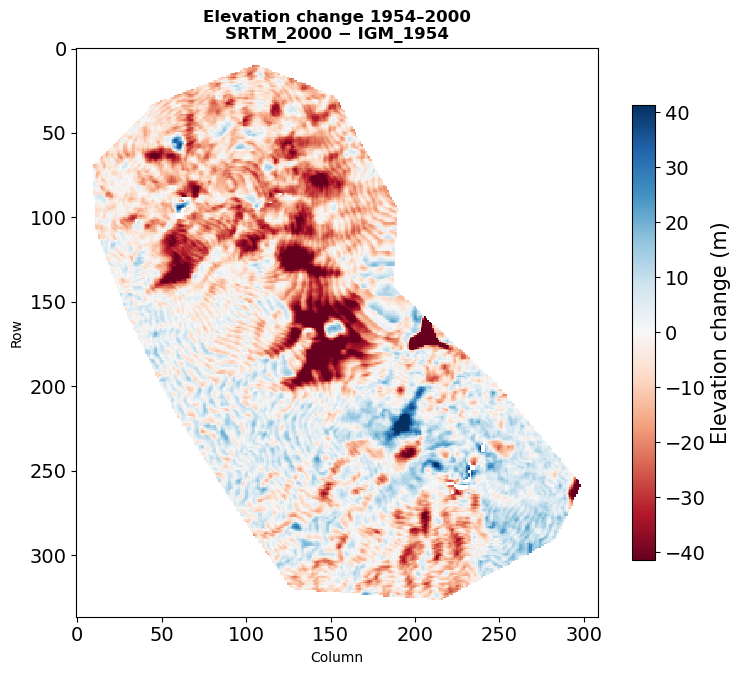

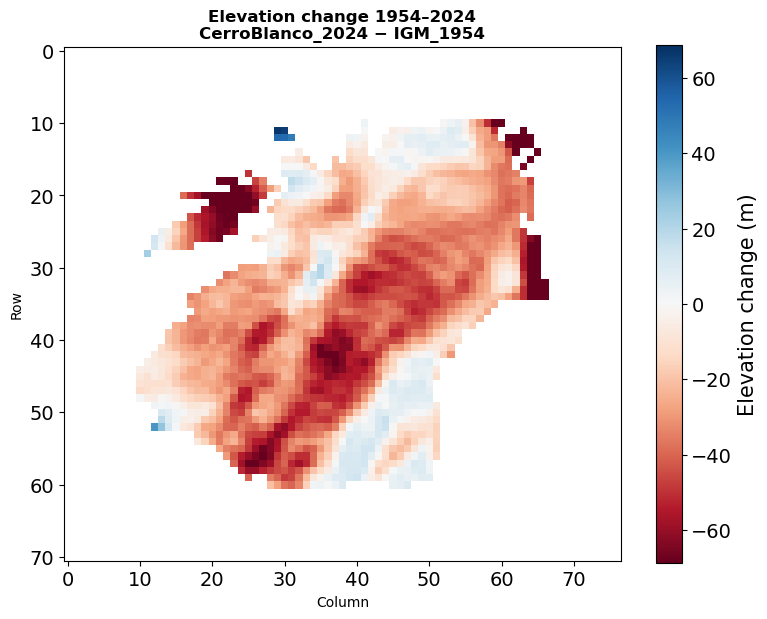

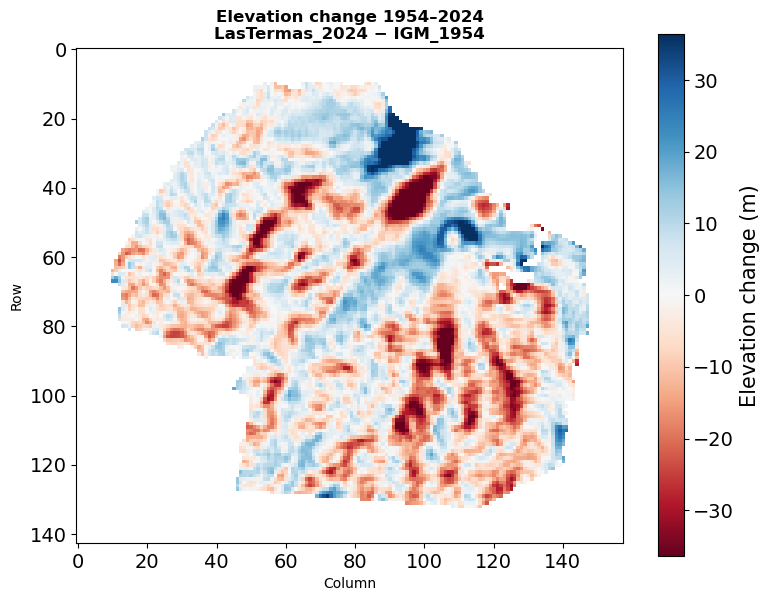

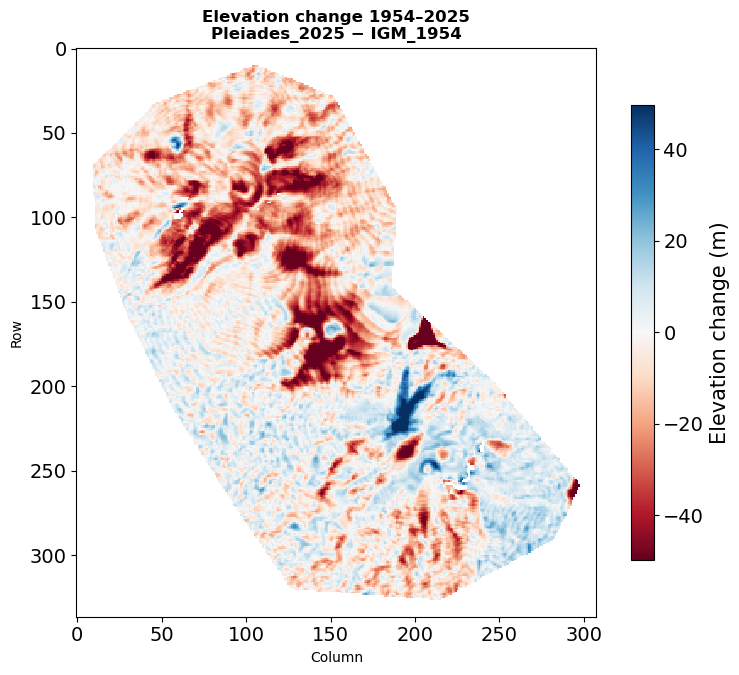

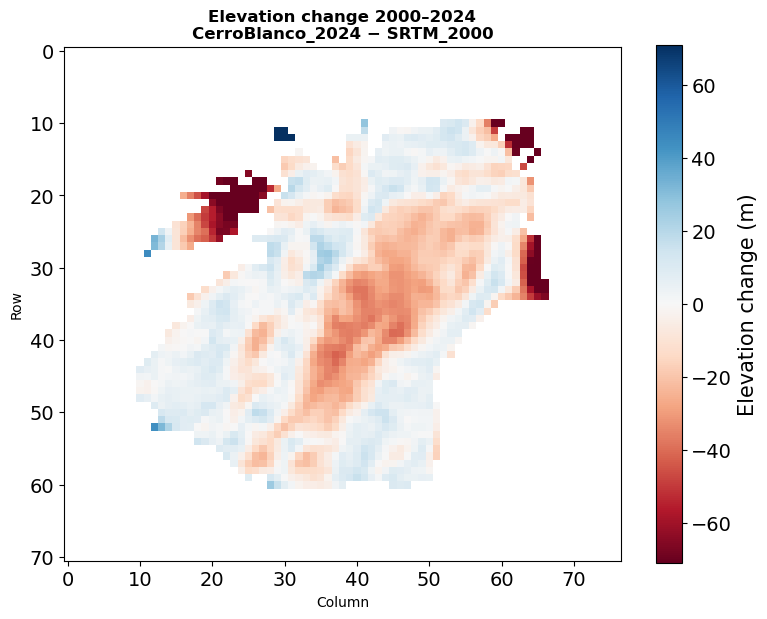

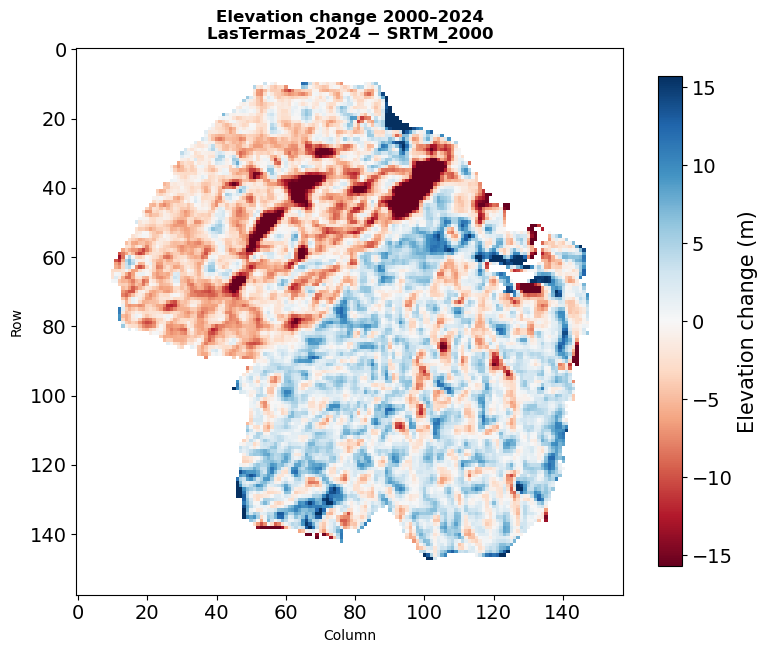

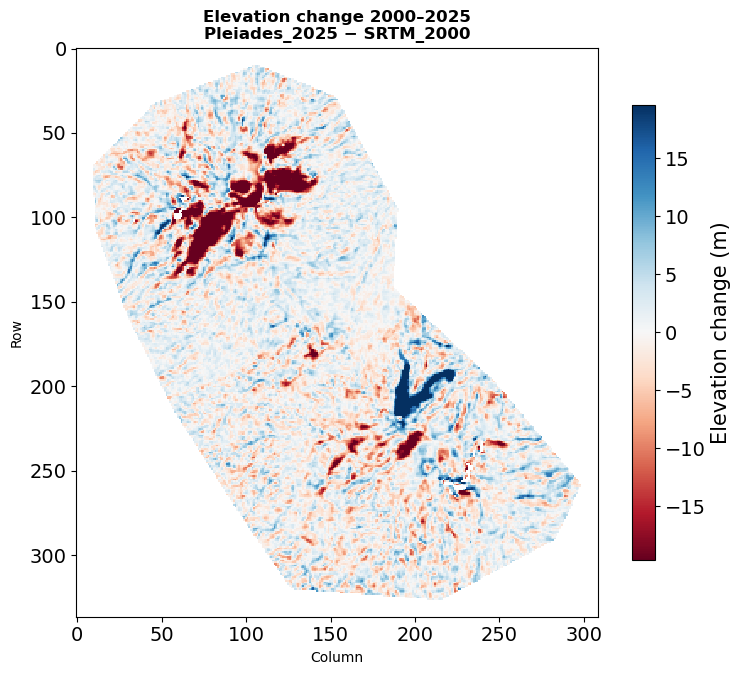

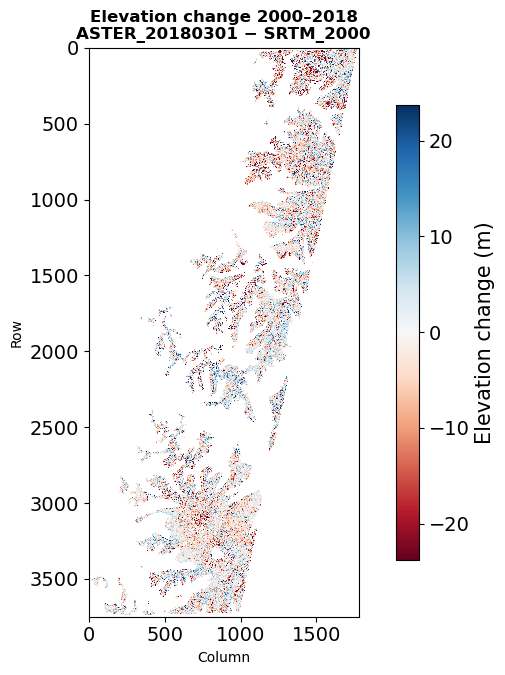

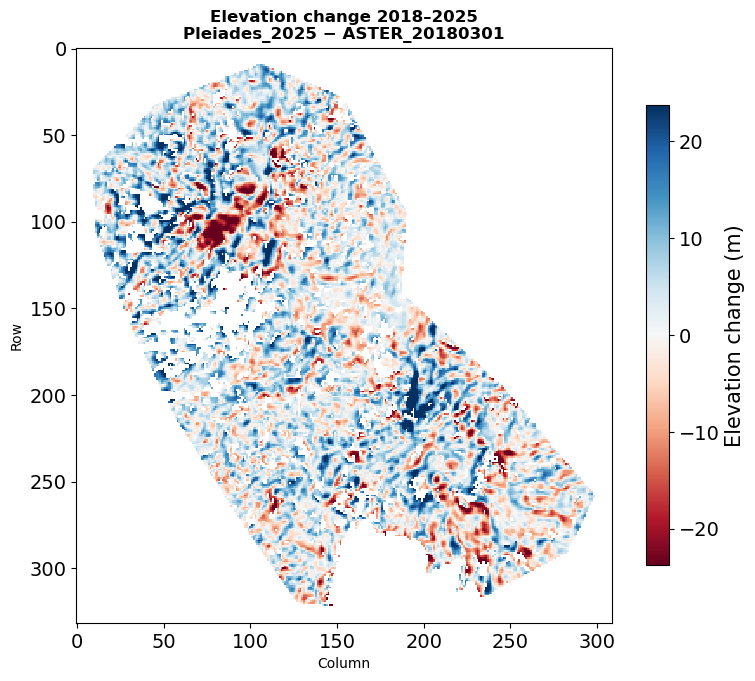

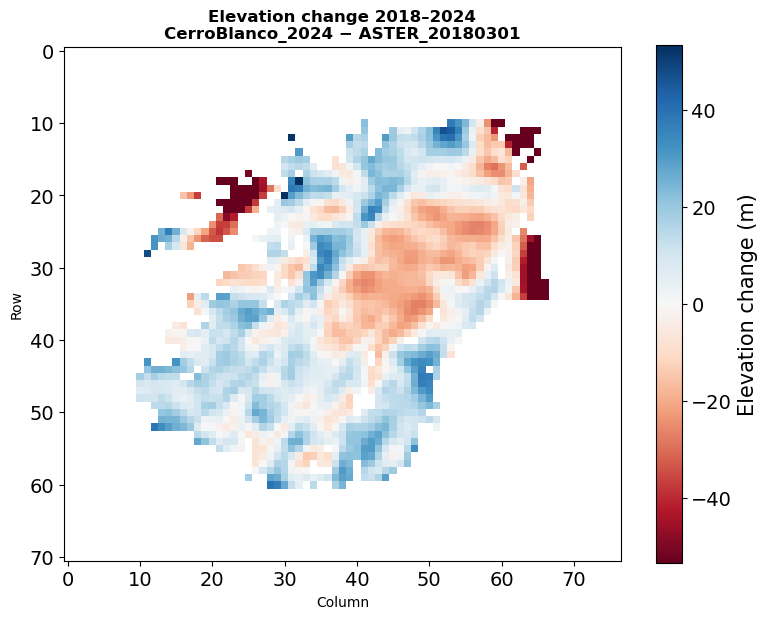

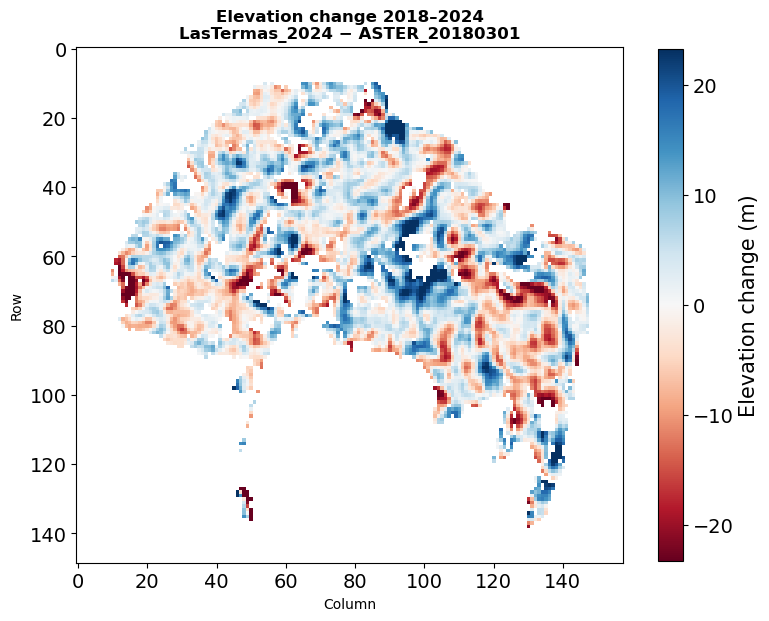

Done.


In [42]:
# --- 6a: dh maps ---
print("\nGenerating dh maps...")

EPOCHS = [
    ("SRTM_2000",         "IGM_1954",        "1975", "2000",      1954, 2000),
    ("CerroBlanco_2024",  "IGM_1954",        "1975", "2000",      1954, 2024),
    ("LasTermas_2024",    "IGM_1954",        "1975", "2000",      1954, 2024),
    ("Pleiades_2025",     "IGM_1954",        "1975", "2000+2019", 1954, 2025),
    ("CerroBlanco_2024",  "SRTM_2000",       "2000", "2019",      2000, 2024),
    ("LasTermas_2024",    "SRTM_2000",       "2000", "2019",      2000, 2024),
    ("Pleiades_2025",     "SRTM_2000",       "2000", "2019",      2000, 2025),
    ("ASTER_20180301",    "SRTM_2000",       "2000", "2019",      2000, 2018),
    ("Pleiades_2025",     "ASTER_20180301",  "2000", "2019",      2018, 2025),
    ("CerroBlanco_2024",  "ASTER_20180301",  "2000", "2019",      2018, 2024),
    ("LasTermas_2024",    "ASTER_20180301",  "2000", "2019",      2018, 2024),
]

for current_name, baseline_name, clip_outline, end_outline, t_start, t_end in EPOCHS:
    epoch_label = f"{current_name}_minus_{baseline_name}"
    dh_path     = os.path.join(output_folder, f"{epoch_label}_dh.tif")
    if not os.path.exists(dh_path):
        print(f"  SKIP (not found): {epoch_label}")
        continue

    with rasterio.open(dh_path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan

        # Crop to valid data extent
    valid_rows = np.any(np.isfinite(data), axis=1)
    valid_cols = np.any(np.isfinite(data), axis=0)
    if valid_rows.any() and valid_cols.any():
        rmin, rmax = np.where(valid_rows)[0][[0, -1]]
        cmin, cmax = np.where(valid_cols)[0][[0, -1]]
        pad = 10  # pixel padding around glacier
        rmin = max(0, rmin - pad)
        rmax = min(data.shape[0] - 1, rmax + pad)
        cmin = max(0, cmin - pad)
        cmax = min(data.shape[1] - 1, cmax + pad)
        data = data[rmin:rmax+1, cmin:cmax+1]

    valid = data[np.isfinite(data)]
    if len(valid) == 0:
        print(f"  SKIP (no valid pixels): {epoch_label}")
        continue

    abs_max = np.nanpercentile(np.abs(valid), 97)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(data, cmap='RdBu', vmin=-abs_max, vmax=abs_max,
                   interpolation='nearest', aspect='equal')
    plt.colorbar(im, ax=ax, label='Elevation change (m)', shrink=0.8)
    ax.set_title(f'Elevation change {t_start}–{t_end}\n'
                 f'{current_name} − {baseline_name}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Column', fontsize=10)
    ax.set_ylabel('Row',    fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(figures_folder, f"dh_map_{epoch_label}.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print("Done.")


Generating dh map figures...
Loading Fig 3 panel data (1954-based epochs)...
Loading Fig 4 panel data (2000/2018-based epochs)...
Rendering Fig 3...


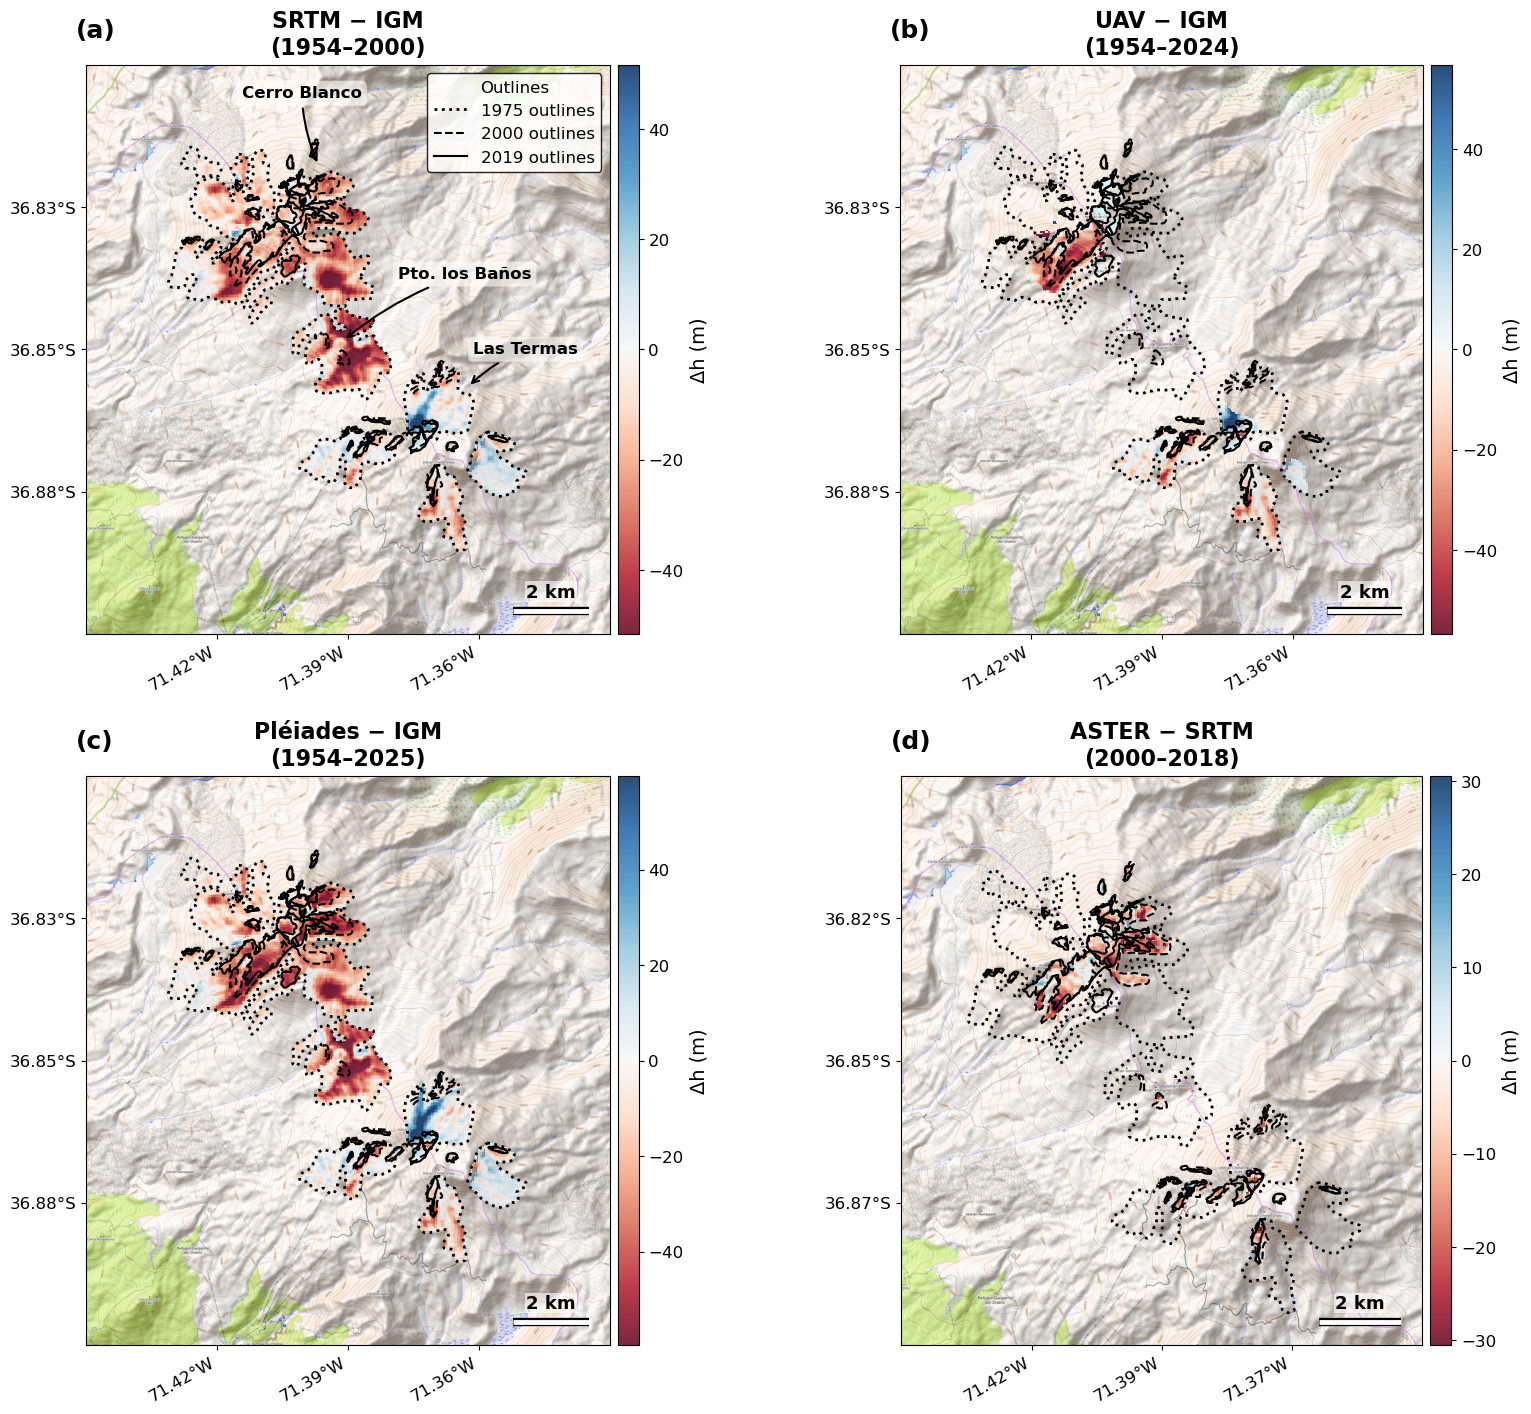

Saved: fig03_dh_maps_1954based.png
Rendering Fig 4...


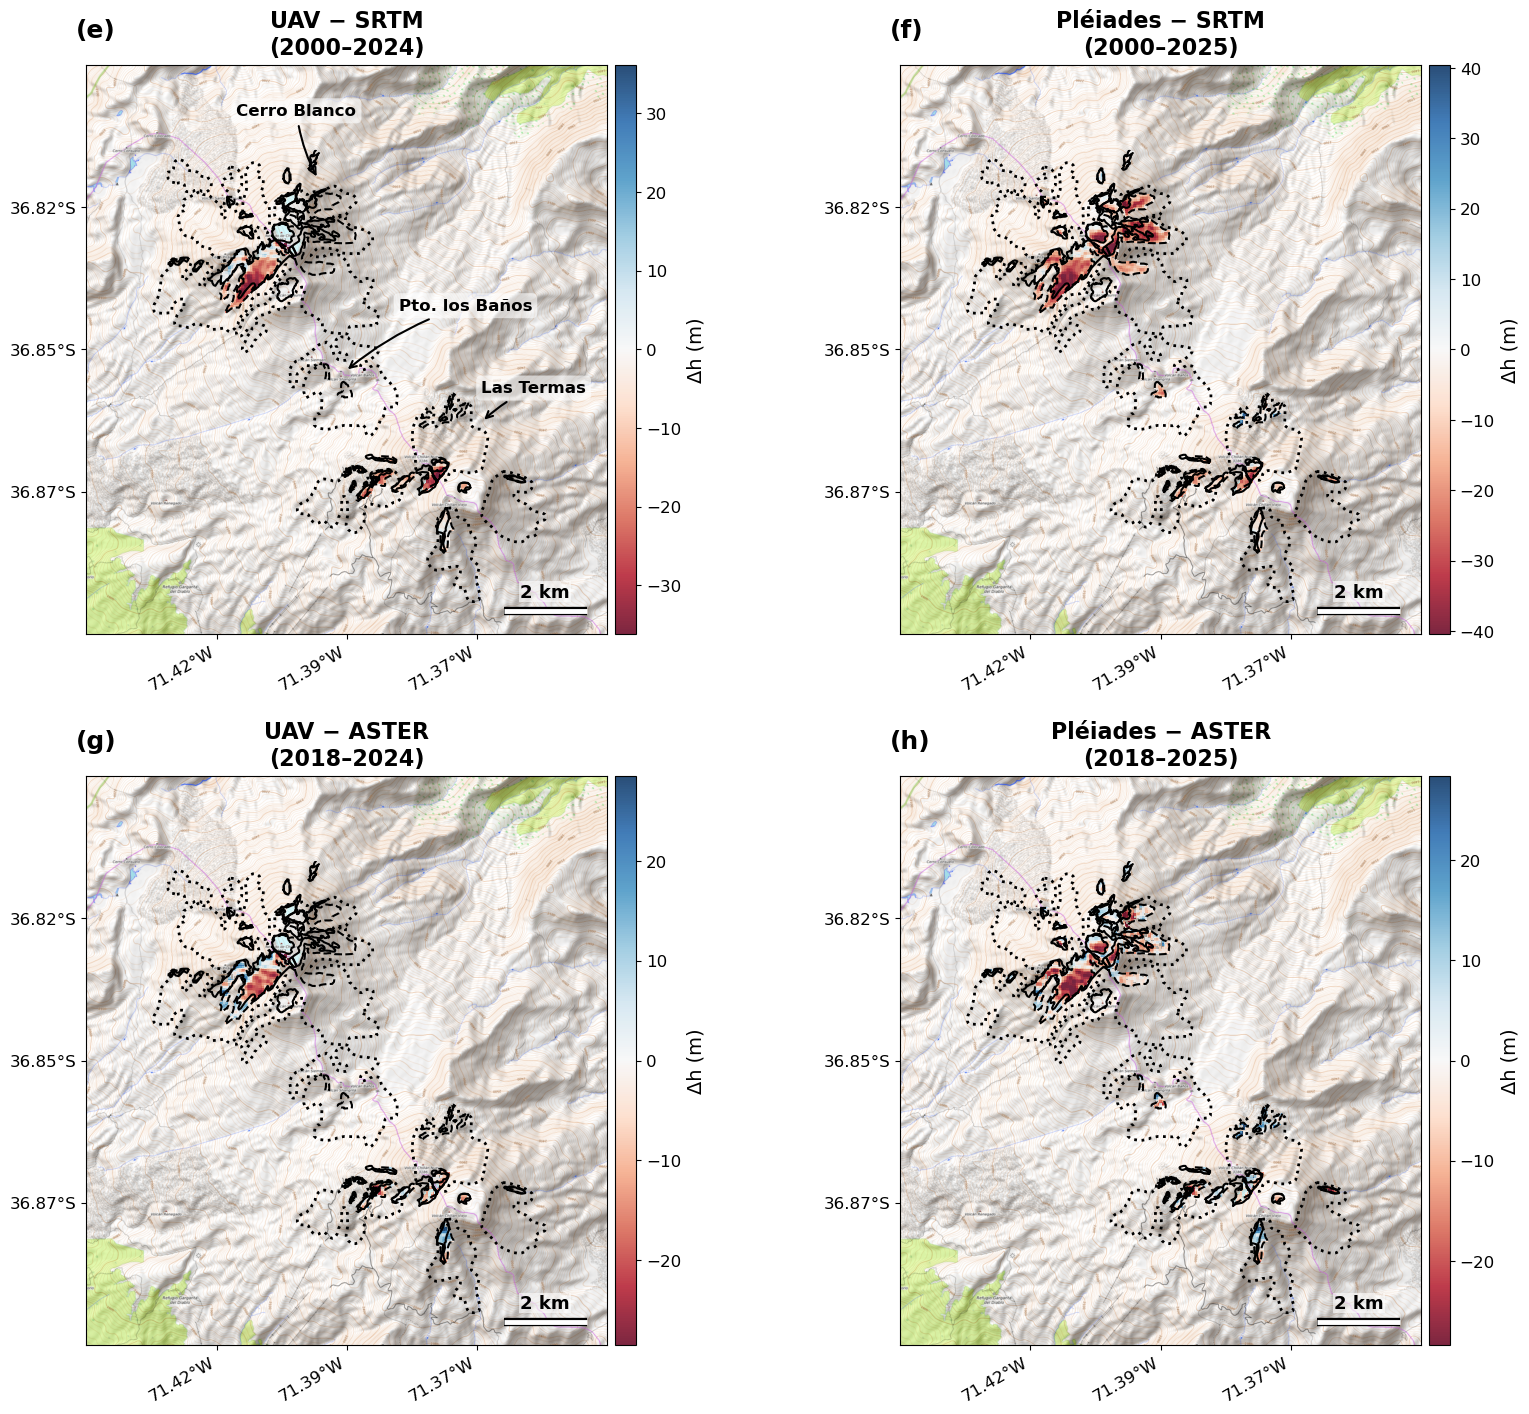

Saved: fig04_dh_maps_2000based.png


In [43]:
# --- 6a: dh map figures — split into Fig 3 and Fig 4 ---
print("\nGenerating dh map figures...")

from rasterio.mask import mask as rio_mask_fn
from rasterio.warp import reproject, Resampling, calculate_default_transform
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyproj import Transformer
import matplotlib.colors as mcolors

plt.rcParams.update({
    'font.size':        16,
    'axes.titlesize':   16,
    'axes.labelsize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  13,
})

_to_latlon = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)

gdf_1975_plot = gpd.read_file(glacier_1975_path).to_crs('EPSG:3857')
gdf_2000_plot = gpd.read_file(glacier_2000_path).to_crs('EPSG:3857')
gdf_2019_plot = gpd.read_file(glacier_2019_path).to_crs('EPSG:3857')
gdf_2019_plot['COD_GLA'] = gdf_2019_plot['COD_GLA'].str.rstrip('@')

OUTLINE_STYLES = [
    (gdf_1975_plot, 2.0, ':',  '1975 outlines'),
    (gdf_2000_plot, 1.5, '--', '2000 outlines'),
    (gdf_2019_plot, 1.5, '-',  '2019 outlines'),
]

# ── Fig 3: 1954-based epochs ──────────────────────────────────────────────────
PANELS_FIG3 = [
    ('single',
     ("SRTM_2000", "IGM_1954", "1975", "2000", 1954, 2000),
     'SRTM − IGM\n(1954–2000)'),
    ('pair',
     (("CerroBlanco_2024","IGM_1954","1975",1954,2024),
      ("LasTermas_2024",  "IGM_1954","1975",1954,2024)),
     'UAV − IGM\n(1954–2024)'),
    ('single',
     ("Pleiades_2025", "IGM_1954", "1975", "2000+2019", 1954, 2025),
     'Pléiades − IGM\n(1954–2025)'),
    ('single',
     ("ASTER_20180301", "SRTM_2000", "2000", "2019", 2000, 2018),
     'ASTER − SRTM\n(2000–2018)'),
]

# ── Fig 4: 2000/2018-based epochs ─────────────────────────────────────────────
PANELS_FIG4 = [
    ('pair',
     (("CerroBlanco_2024","SRTM_2000","2000",2000,2024),
      ("LasTermas_2024",  "SRTM_2000","2000",2000,2024)),
     'UAV − SRTM\n(2000–2024)'),
    ('single',
     ("Pleiades_2025", "SRTM_2000", "2000", "2019", 2000, 2025),
     'Pléiades − SRTM\n(2000–2025)'),
    ('pair',
     (("CerroBlanco_2024","ASTER_20180301","2000",2018,2024),
      ("LasTermas_2024",  "ASTER_20180301","2000",2018,2024)),
     'UAV − ASTER\n(2018–2024)'),
    ('single',
     ("Pleiades_2025", "ASTER_20180301", "2000", "2019", 2018, 2025),
     'Pléiades − ASTER\n(2018–2025)'),
]

PAD_FRAC = 0.20

# colormap with transparent NaN
cmap_dh = plt.colormaps['RdBu'].copy()
cmap_dh.set_bad(alpha=0)


def load_clip_dh(dh_path, clip_gdf):
    with rasterio.open(dh_path) as src:
        clip_proj = clip_gdf.to_crs(src.crs)
        geoms = [g.__geo_interface__ for g in clip_proj.geometry
                 if g is not None and not g.is_empty]
        try:
            clipped, tfm = rio_mask_fn(src, geoms, crop=True,
                                        nodata=np.nan, filled=True)
            data = clipped[0].astype(float)
            data[data == src.nodata] = np.nan
        except Exception:
            data = src.read(1).astype(float)
            data[data == src.nodata] = np.nan
            tfm = src.transform
        src_crs = src.crs
        nrows, ncols = data.shape
    dst_crs = 'EPSG:3857'
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, dst_crs, ncols, nrows,
        *rasterio.transform.array_bounds(nrows, ncols, tfm))
    dst_data = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
    reproject(source=data.astype(np.float32), destination=dst_data,
              src_transform=tfm, src_crs=src_crs,
              dst_transform=dst_transform, dst_crs=dst_crs,
              resampling=Resampling.bilinear,
              src_nodata=np.nan, dst_nodata=np.nan)
    dst_data[np.abs(dst_data) > 200] = np.nan
    bounds = rasterio.transform.array_bounds(dst_height, dst_width, dst_transform)
    xmin, ymin, xmax, ymax = bounds
    extent = [xmin, xmax, ymin, ymax]
    xpad = (xmax - xmin) * PAD_FRAC
    ypad = (ymax - ymin) * PAD_FRAC
    xlim = (xmin - xpad, xmax + xpad)
    ylim = (ymin - ypad, ymax + ypad)
    return dst_data, extent, xlim, ylim


def set_latlon_ticks(ax, n_xticks=3, n_yticks=3):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xtick_vals = np.linspace(xlim[0], xlim[1], n_xticks + 2)[1:-1]
    ytick_vals = np.linspace(ylim[0], ylim[1], n_yticks + 2)[1:-1]
    y_mid = (ylim[0] + ylim[1]) / 2
    x_mid = (xlim[0] + xlim[1]) / 2
    xlons = [_to_latlon.transform(x, y_mid)[0] for x in xtick_vals]
    ylats = [_to_latlon.transform(x_mid, y)[1] for y in ytick_vals]
    ax.set_xticks(xtick_vals)
    ax.set_yticks(ytick_vals)
    ax.set_xticklabels([f'{abs(lon):.2f}°{"W" if lon < 0 else "E"}'
                        for lon in xlons], fontsize=12, rotation=30, ha='right')
    ax.set_yticklabels([f'{abs(lat):.2f}°{"S" if lat < 0 else "N"}'
                        for lat in ylats], fontsize=12)
    # ax.set_xlabel('Longitude', fontsize=13)
    # ax.set_ylabel('Latitude',  fontsize=13)


def get_scalebar_length(xlim):
    width_km = (xlim[1] - xlim[0]) / 1000
    if   width_km > 20: return 5000
    elif width_km > 10: return 2000
    elif width_km >  4: return 1000
    else:               return 500


def add_scalebar(ax):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    length_m = get_scalebar_length(xlim)
    x1 = xlim[0] + (xlim[1] - xlim[0]) * 0.96
    x0 = x1 - length_m
    y  = ylim[0] + (ylim[1] - ylim[0]) * 0.04
    dy = (ylim[1] - ylim[0]) * 0.018
    ax.plot([x0, x1], [y, y], color='black', lw=6,
            solid_capstyle='butt', zorder=5)
    ax.plot([x0, x1], [y, y], color='white', lw=3.5,
            solid_capstyle='butt', zorder=6)
    label = f'{length_m/1000:.0f} km' if length_m >= 1000 else f'{int(length_m)} m'
    ax.text((x0 + x1) / 2, y + dy, label,
            color='black', ha='center', va='bottom', fontsize=13,
            fontweight='bold', zorder=7,
            bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))


def add_outlines(ax):
    for gdf, lw, ls, _ in OUTLINE_STYLES:
        for geom in gdf.geometry:
            if geom is None or geom.is_empty:
                continue
            polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
            for poly in polys:
                ax.plot(*poly.exterior.xy, color='black', lw=lw, ls=ls,
                        label='_nolegend_', zorder=5)


def add_outline_legend(ax):
    handles = [
        Line2D([0],[0], color='black', lw=2.0, ls=':',  label='1975 outlines'),
        Line2D([0],[0], color='black', lw=1.5, ls='--', label='2000 outlines'),
        Line2D([0],[0], color='black', lw=1.5, ls='-',  label='2019 outlines'),
    ]
    ax.legend(handles=handles, loc='upper right',
              fontsize=12, framealpha=0.85, edgecolor='black',
              title='Outlines', title_fontsize=12)


def add_subcomplex_labels(ax):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    dx = (xlim[1] - xlim[0]) * 0.12
    dy = (ylim[1] - ylim[0]) * 0.12

    label_offsets = {
        'Cerro Blanco':   (-dx * 0.4,  dy * 1.5),
        'Las Termas':     ( dx,         dy),
        'Pto. los Baños': ( dx,         dy),
    }
    subcomplex_groups = {
        'Cerro Blanco':   gdf_2000_plot[gdf_2000_plot['COD_GLA'].isin(CERRO_BLANCO_GLACIERS)],
        'Las Termas':     gdf_2000_plot[gdf_2000_plot['COD_GLA'].isin(LASTERMAS_GLACIERS)],
        'Pto. los Baños': gdf_2000_plot[gdf_2000_plot['COD_GLA'].isin(SADDLE_GLACIERS)],
    }
    for name, gdf in subcomplex_groups.items():
        if len(gdf) == 0:
            continue
        cx = gdf.geometry.centroid.x.mean()
        cy = gdf.geometry.centroid.y.mean()
        hull = gdf.geometry.union_all().convex_hull
        tip_x = cx + (hull.bounds[2] - cx) * 0.6
        tip_y = cy + (hull.bounds[3] - cy) * 0.6
        odx, ody = label_offsets[name]
        ax.annotate(
            name,
            xy=(tip_x, tip_y),
            xytext=(cx + odx, cy + ody),
            fontsize=12, fontweight='bold', color='black',
            ha='left', va='bottom', zorder=9,
            bbox=dict(facecolor='white', alpha=0.6,
                      pad=2, edgecolor='none', boxstyle='round,pad=0.3'),
            arrowprops=dict(arrowstyle='->', color='black',
                            lw=1.5, connectionstyle='arc3,rad=0.1'),
        )


def finalise_ax(ax, xlim, ylim, title, letter,
                add_legend=False, add_labels=False):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    add_scalebar(ax)
    set_latlon_ticks(ax)
    if add_legend:
        add_outline_legend(ax)
    if add_labels:
        add_subcomplex_labels(ax)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=8)
    ax.text(-0.02, 1.04, letter, transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='bottom', ha='left',
            color='black')


def render_single_panel(ax, pd_item, letter,
                        add_legend=False, add_labels=False):
    xlim, ylim = pd_item['xlim'], pd_item['ylim']
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    try:
        ctx.add_basemap(ax, crs='EPSG:3857',
                        source=ctx.providers.OpenTopoMap,
                        zoom=14, attribution=False)
    except Exception as e:
        print(f'    Basemap failed ({letter}): {e}')
    im = ax.imshow(pd_item['data'], extent=pd_item['extent'],
                   origin='upper', cmap=cmap_dh,
                   vmin=-pd_item['abs_max'], vmax=pd_item['abs_max'],
                   interpolation='nearest', alpha=0.85)
    add_outlines(ax)
    finalise_ax(ax, xlim, ylim, pd_item['title'], letter,
                add_legend=add_legend, add_labels=add_labels)
    return im


def render_pair_panel(ax, pd_item, letter,
                      add_legend=False, add_labels=False):
    xlim, ylim = pd_item['xlim'], pd_item['ylim']
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    try:
        ctx.add_basemap(ax, crs='EPSG:3857',
                        source=ctx.providers.OpenTopoMap,
                        zoom=14, attribution=False)
    except Exception as e:
        print(f'    Basemap failed ({letter}): {e}')
    abs_max = pd_item['abs_max']
    im = None
    if len(pd_item['cb_data'][np.isfinite(pd_item['cb_data'])]) > 0:
        im = ax.imshow(pd_item['cb_data'], extent=pd_item['cb_ext'],
                       origin='upper', cmap=cmap_dh,
                       vmin=-abs_max, vmax=abs_max,
                       interpolation='nearest', alpha=0.85)
    if len(pd_item['lt_data'][np.isfinite(pd_item['lt_data'])]) > 0:
        im = ax.imshow(pd_item['lt_data'], extent=pd_item['lt_ext'],
                       origin='upper', cmap=cmap_dh,
                       vmin=-abs_max, vmax=abs_max,
                       interpolation='nearest', alpha=0.85)
    add_outlines(ax)
    finalise_ax(ax, xlim, ylim, pd_item['title'], letter,
                add_legend=add_legend, add_labels=add_labels)
    return im


def load_panel_set(panel_list):
    panel_data = []
    for ptype, epoch_data, title in panel_list:
        if ptype == 'single':
            current_name, baseline_name, clip_outline, _, t_start, t_end = epoch_data
            dh_path  = os.path.join(output_folder,
                                    f"{current_name}_minus_{baseline_name}_dh.tif")
            clip_gdf = gdf_1975_plot if clip_outline == '1975' else gdf_2000_plot
            if not os.path.exists(dh_path):
                print(f"  MISSING: {current_name}_minus_{baseline_name}")
                panel_data.append(None)
                continue
            data, extent, xlim, ylim = load_clip_dh(dh_path, clip_gdf)
            valid   = data[np.isfinite(data)]
            abs_max = max(np.nanpercentile(np.abs(valid), 97), 10) if len(valid) > 0 else 10
            panel_data.append({'type': 'single', 'data': data, 'extent': extent,
                               'xlim': xlim, 'ylim': ylim,
                               'abs_max': abs_max, 'title': title})
        else:
            cb_ep, lt_ep = epoch_data
            cb_name, cb_base, cb_clip, cb_start, cb_end = cb_ep
            lt_name, lt_base, lt_clip, lt_start, lt_end = lt_ep
            cb_path     = os.path.join(output_folder,
                                       f"{cb_name}_minus_{cb_base}_dh.tif")
            lt_path     = os.path.join(output_folder,
                                       f"{lt_name}_minus_{lt_base}_dh.tif")
            cb_clip_gdf = gdf_1975_plot if cb_clip == '1975' else gdf_2000_plot
            lt_clip_gdf = gdf_1975_plot if lt_clip == '1975' else gdf_2000_plot
            if not os.path.exists(cb_path) or not os.path.exists(lt_path):
                print(f"  MISSING pair: {cb_name}_minus_{cb_base}")
                panel_data.append(None)
                continue
            cb_data, cb_ext, cb_xlim, cb_ylim = load_clip_dh(cb_path, cb_clip_gdf)
            lt_data, lt_ext, lt_xlim, lt_ylim = load_clip_dh(lt_path, lt_clip_gdf)
            cb_valid = cb_data[np.isfinite(cb_data)]
            lt_valid = lt_data[np.isfinite(lt_data)]
            combined = np.concatenate([v for v in [cb_valid, lt_valid] if len(v) > 0])
            abs_max  = max(np.nanpercentile(np.abs(combined), 97), 10) if len(combined) > 0 else 10
            xlim = (min(cb_xlim[0], lt_xlim[0]), max(cb_xlim[1], lt_xlim[1]))
            ylim = (min(cb_ylim[0], lt_ylim[0]), max(cb_ylim[1], lt_ylim[1]))
            panel_data.append({'type': 'pair',
                               'cb_data': cb_data, 'cb_ext': cb_ext,
                               'lt_data': lt_data, 'lt_ext': lt_ext,
                               'xlim': xlim, 'ylim': ylim,
                               'abs_max': abs_max, 'title': title})
    return panel_data


def render_figure(panel_data, letters, fig_path,
                  fig_title=None, show_legend=True):
    fig, axes = plt.subplots(2, 2, figsize=(18, 16),
                             constrained_layout=False,
                             gridspec_kw={'hspace': 0.25, 'wspace': 0.40})
    axes_flat = axes.flatten()

    for idx, (pd_item, ax, letter) in enumerate(zip(panel_data, axes_flat, letters)):
        if pd_item is None:
            ax.set_visible(False)
            continue
        add_legend = (idx == 0) and show_legend
        add_labels = (idx == 0)
        if pd_item['type'] == 'pair':
            im = render_pair_panel(ax, pd_item, letter,
                                   add_legend=add_legend, add_labels=add_labels)
        else:
            im = render_single_panel(ax, pd_item, letter,
                                     add_legend=add_legend, add_labels=add_labels)
        if im is not None:
            divider = make_axes_locatable(ax)
            cax     = divider.append_axes('right', size='4%', pad=0.08)
            cb      = fig.colorbar(im, cax=cax)
            cb.set_label('Δh (m)', fontsize=14)
            cb.ax.tick_params(labelsize=12)

    if fig_title:
        fig.suptitle(fig_title, fontsize=18, fontweight='bold', y=1.01)

    # fig.text(0.5, -0.01,
    #          'Basemap: © OpenTopoMap contributors',
    #          ha='center', fontsize=11, color='#555555', style='italic')
    fig.subplots_adjust(bottom=0.08)
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(fig_path)}')


# ── Load and render ───────────────────────────────────────────────────────────
print("Loading Fig 3 panel data (1954-based epochs)...")
panel_data_fig3 = load_panel_set(PANELS_FIG3)
letters_fig3    = ['(a)', '(b)', '(c)', '(d)']

print("Loading Fig 4 panel data (2000/2018-based epochs)...")
panel_data_fig4 = load_panel_set(PANELS_FIG4)
letters_fig4    = ['(e)', '(f)', '(g)', '(h)']

print("Rendering Fig 3...")
render_figure(panel_data_fig3, letters_fig3,
              os.path.join(figures_folder, 'fig03_dh_maps_1954based.png'),
              show_legend=True)

print("Rendering Fig 4...")
render_figure(panel_data_fig4, letters_fig4,
              os.path.join(figures_folder, 'fig04_dh_maps_2000based.png'),
              show_legend=False)

In [44]:
df = pd.read_csv('results/glacier_elevation_change_results.csv')

outline_map = {
    (1954, 2000): 1975,
    (1954, 2024): 1975,
    (1954, 2025): 1975,
    (2000, 2004): 2000,
    (2000, 2007): 2000,
    (2000, 2008): 2000,
    (2000, 2018): 2000,
    (2000, 2024): 2000,
    (2000, 2025): 2000,
}
epoch_subcomplex = {
    'CerroBlanco_2024_minus_IGM_1954':  [GLACIAR_NEVADO],
    'CerroBlanco_2024_minus_SRTM_2000': [GLACIAR_NEVADO],
    'LasTermas_2024_minus_IGM_1954':    LASTERMAS_GLACIERS,
    'LasTermas_2024_minus_SRTM_2000':   LASTERMAS_GLACIERS,
    'Pleiades_2025_minus_IGM_1954':     ALL_GLACIERS,
    'Pleiades_2025_minus_SRTM_2000':    ALL_GLACIERS,
    'Pleiades_2025_minus_ASTER_20180301': ALL_GLACIERS,
    'SRTM_2000_minus_IGM_1954':         ALL_GLACIERS,
    'ASTER_20040326_minus_SRTM_2000':   CERRO_BLANCO_GLACIERS,
    'ASTER_20070224_minus_SRTM_2000':   LASTERMAS_GLACIERS,
    'ASTER_20080330_minus_SRTM_2000':   ALL_GLACIERS,
    'ASTER_20180301_minus_SRTM_2000':   ALL_GLACIERS,
}

results_summary = []

for (t_start, t_end), outline_set in outline_map.items():
    subset = df[
        (df['t_start']      == t_start) &
        (df['t_end']        == t_end)   &
        (df['clip_outline'] == outline_set) &
        (df['mb_mwe_yr'].notna())
    ]
    if subset.empty:
        continue

    for epoch in subset['epoch'].unique():
        ep = subset[subset['epoch'] == epoch]

        # For 1975-based epochs don't filter by glacier ID
        if outline_set != 1975:
            valid_glaciers = epoch_subcomplex.get(epoch, ALL_GLACIERS)
            ep = ep[ep['COD_GLA'].isin(valid_glaciers)]

        if ep.empty:
            continue

        total_area = ep['area_mean_m2'].sum()
        wt_mean    = (ep['mb_mwe_yr'] * ep['area_mean_m2']).sum() / total_area
        wt_sigma   = (ep['sigma_mb_mwe_yr'] * ep['area_mean_m2']).sum() / total_area

        # Glaciar Nevado — for 1975-based epochs look up directly from full df
        # since 1975 polygons don't have matching COD_GLA
        if outline_set == 1975:
            nev_rows = df[
                (df['epoch']   == epoch) &
                (df['COD_GLA'] == GLACIAR_NEVADO) &
                (df['mb_mwe_yr'].notna())
            ]
        else:
            nev_rows = ep[ep['COD_GLA'] == GLACIAR_NEVADO]

        nev_mb    = nev_rows['mb_mwe_yr'].values[0]       if len(nev_rows) > 0 else np.nan
        nev_sigma = nev_rows['sigma_mb_mwe_yr'].values[0] if len(nev_rows) > 0 else np.nan

        results_summary.append({
            'epoch':         epoch,
            't_start':       t_start,
            't_end':         t_end,
            'outline_set':   outline_set,
            'complex_mb':    round(wt_mean, 3),
            'complex_sigma': round(wt_sigma, 3),
            'nevado_mb':     round(nev_mb, 3)    if not np.isnan(nev_mb)    else np.nan,
            'nevado_sigma':  round(nev_sigma, 3) if not np.isnan(nev_sigma) else np.nan,
        })

df_summary = pd.DataFrame(results_summary)
print(df_summary.to_string(index=False))

                           epoch  t_start  t_end  outline_set  complex_mb  complex_sigma  nevado_mb  nevado_sigma
        SRTM_2000_minus_IGM_1954     1954   2000         1975      -0.417          0.201        NaN           NaN
 CerroBlanco_2024_minus_IGM_1954     1954   2024         1975      -0.548          0.054        NaN           NaN
   LasTermas_2024_minus_IGM_1954     1954   2024         1975       0.033          0.192        NaN           NaN
    Pleiades_2025_minus_IGM_1954     1954   2025         1975      -0.320          0.133        NaN           NaN
  ASTER_20180301_minus_SRTM_2000     2000   2018         2000      -0.610          0.062     -0.500         0.039
CerroBlanco_2024_minus_SRTM_2000     2000   2024         2000      -0.536          0.297     -0.536         0.297
  LasTermas_2024_minus_SRTM_2000     2000   2024         2000      -0.477          0.166        NaN           NaN
   Pleiades_2025_minus_SRTM_2000     2000   2025         2000      -0.598          0.382

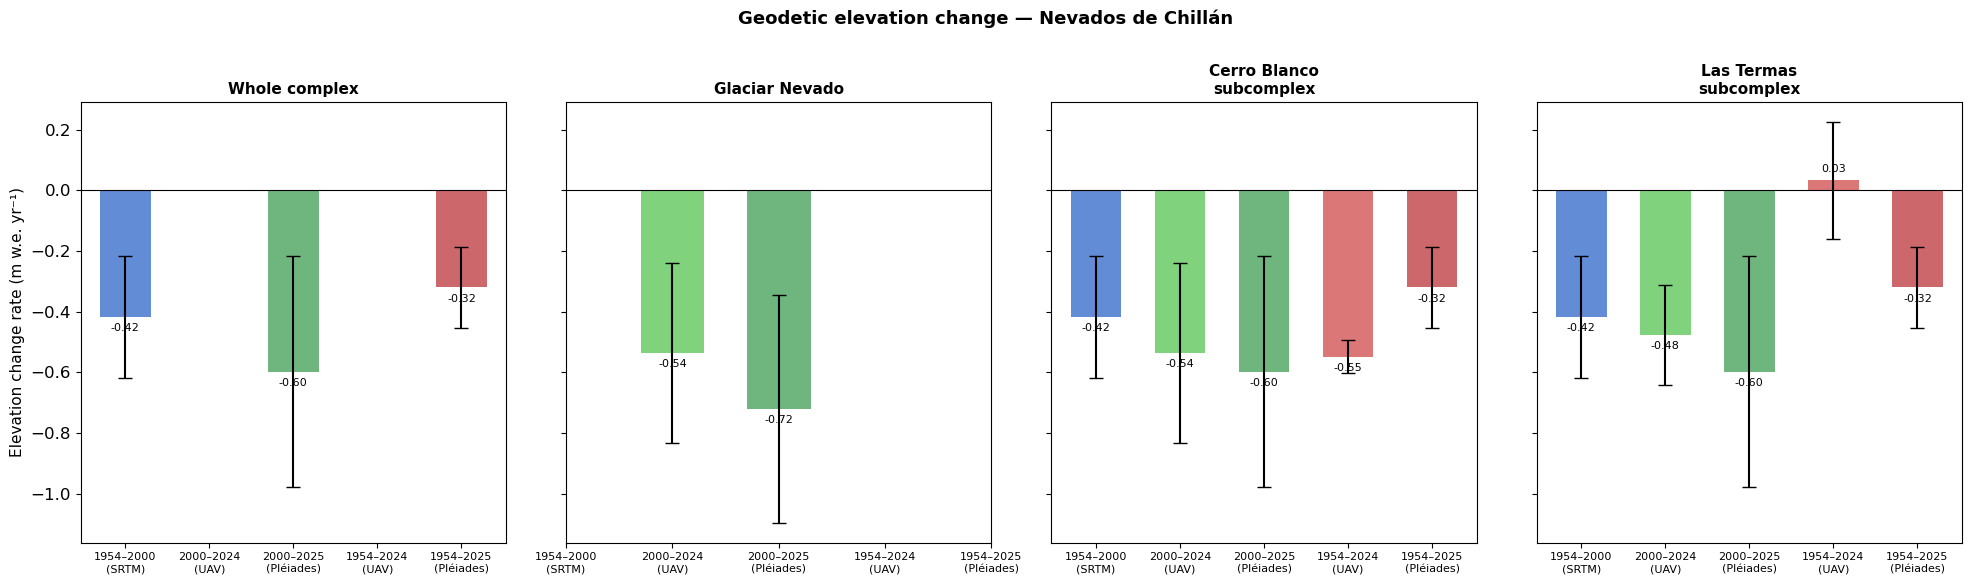

Saved: figures/fig_elevation_change_summary.png


In [45]:
def get_val(epoch, col):
    row = df_summary[df_summary['epoch'] == epoch]
    return row[col].values[0] if len(row) > 0 else np.nan


periods = ['1954–2000\n(SRTM)', '2000–2024\n(UAV)', '2000–2025\n(Pléiades)', '1954–2024\n(UAV)', '1954–2025\n(Pléiades)']

data_by_glacier = {
    'Whole complex': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'complex_mb'),
                  np.nan,
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_mb'),
                  np.nan,
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'complex_sigma'),
                  np.nan,
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_sigma'),
                  np.nan,
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_sigma')],
    },
    'Glaciar Nevado': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'nevado_mb'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','nevado_mb'),
                  get_val('Pleiades_2025_minus_SRTM_2000','nevado_mb'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'nevado_mb'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'nevado_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'nevado_sigma'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','nevado_sigma'),
                  get_val('Pleiades_2025_minus_SRTM_2000','nevado_sigma'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'nevado_sigma'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'nevado_sigma')],
    },
    'Cerro Blanco\nsubcomplex': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'complex_mb'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','complex_mb'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_mb'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'complex_mb'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'complex_sigma'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','complex_sigma'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_sigma'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'complex_sigma'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_sigma')],
    },
    'Las Termas\nsubcomplex': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'complex_mb'),
                  get_val('LasTermas_2024_minus_SRTM_2000','complex_mb'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_mb'),
                  get_val('LasTermas_2024_minus_IGM_1954', 'complex_mb'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'complex_sigma'),
                  get_val('LasTermas_2024_minus_SRTM_2000','complex_sigma'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_sigma'),
                  get_val('LasTermas_2024_minus_IGM_1954', 'complex_sigma'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_sigma')],
    },
}

plt.rcParams.update({'font.family': 'sans-serif'})
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
x     = np.arange(len(periods))
width = 0.6
colors = ['#4878CF', '#6ACC65', '#55A868', '#D65F5F', '#C44E52']

for ax, (glacier, gdata) in zip(axes, data_by_glacier.items()):
    mb    = gdata['mb']
    sigma = gdata['sigma']

    for i, (val, err, col) in enumerate(zip(mb, sigma, colors)):
        if not np.isnan(val):
            ax.bar(x[i], val, width, yerr=err if not np.isnan(err) else 0,
                   capsize=5, color=col, alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(periods, fontsize=8)
    ax.set_title(glacier, fontsize=11, fontweight='bold')

    for i, val in enumerate(mb):
        if not np.isnan(val):
            ax.text(x[i], val - 0.02 if val < 0 else val + 0.02,
                    f'{val:.2f}', ha='center',
                    va='top' if val < 0 else 'bottom', fontsize=8)

axes[0].set_ylabel('Elevation change rate (m w.e. yr⁻¹)', fontsize=11)
fig.suptitle('Geodetic elevation change — Nevados de Chillán',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(figures_folder, 'fig_elevation_change_summary.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', os.path.join(figures_folder, 'fig_elevation_change_summary.png'))

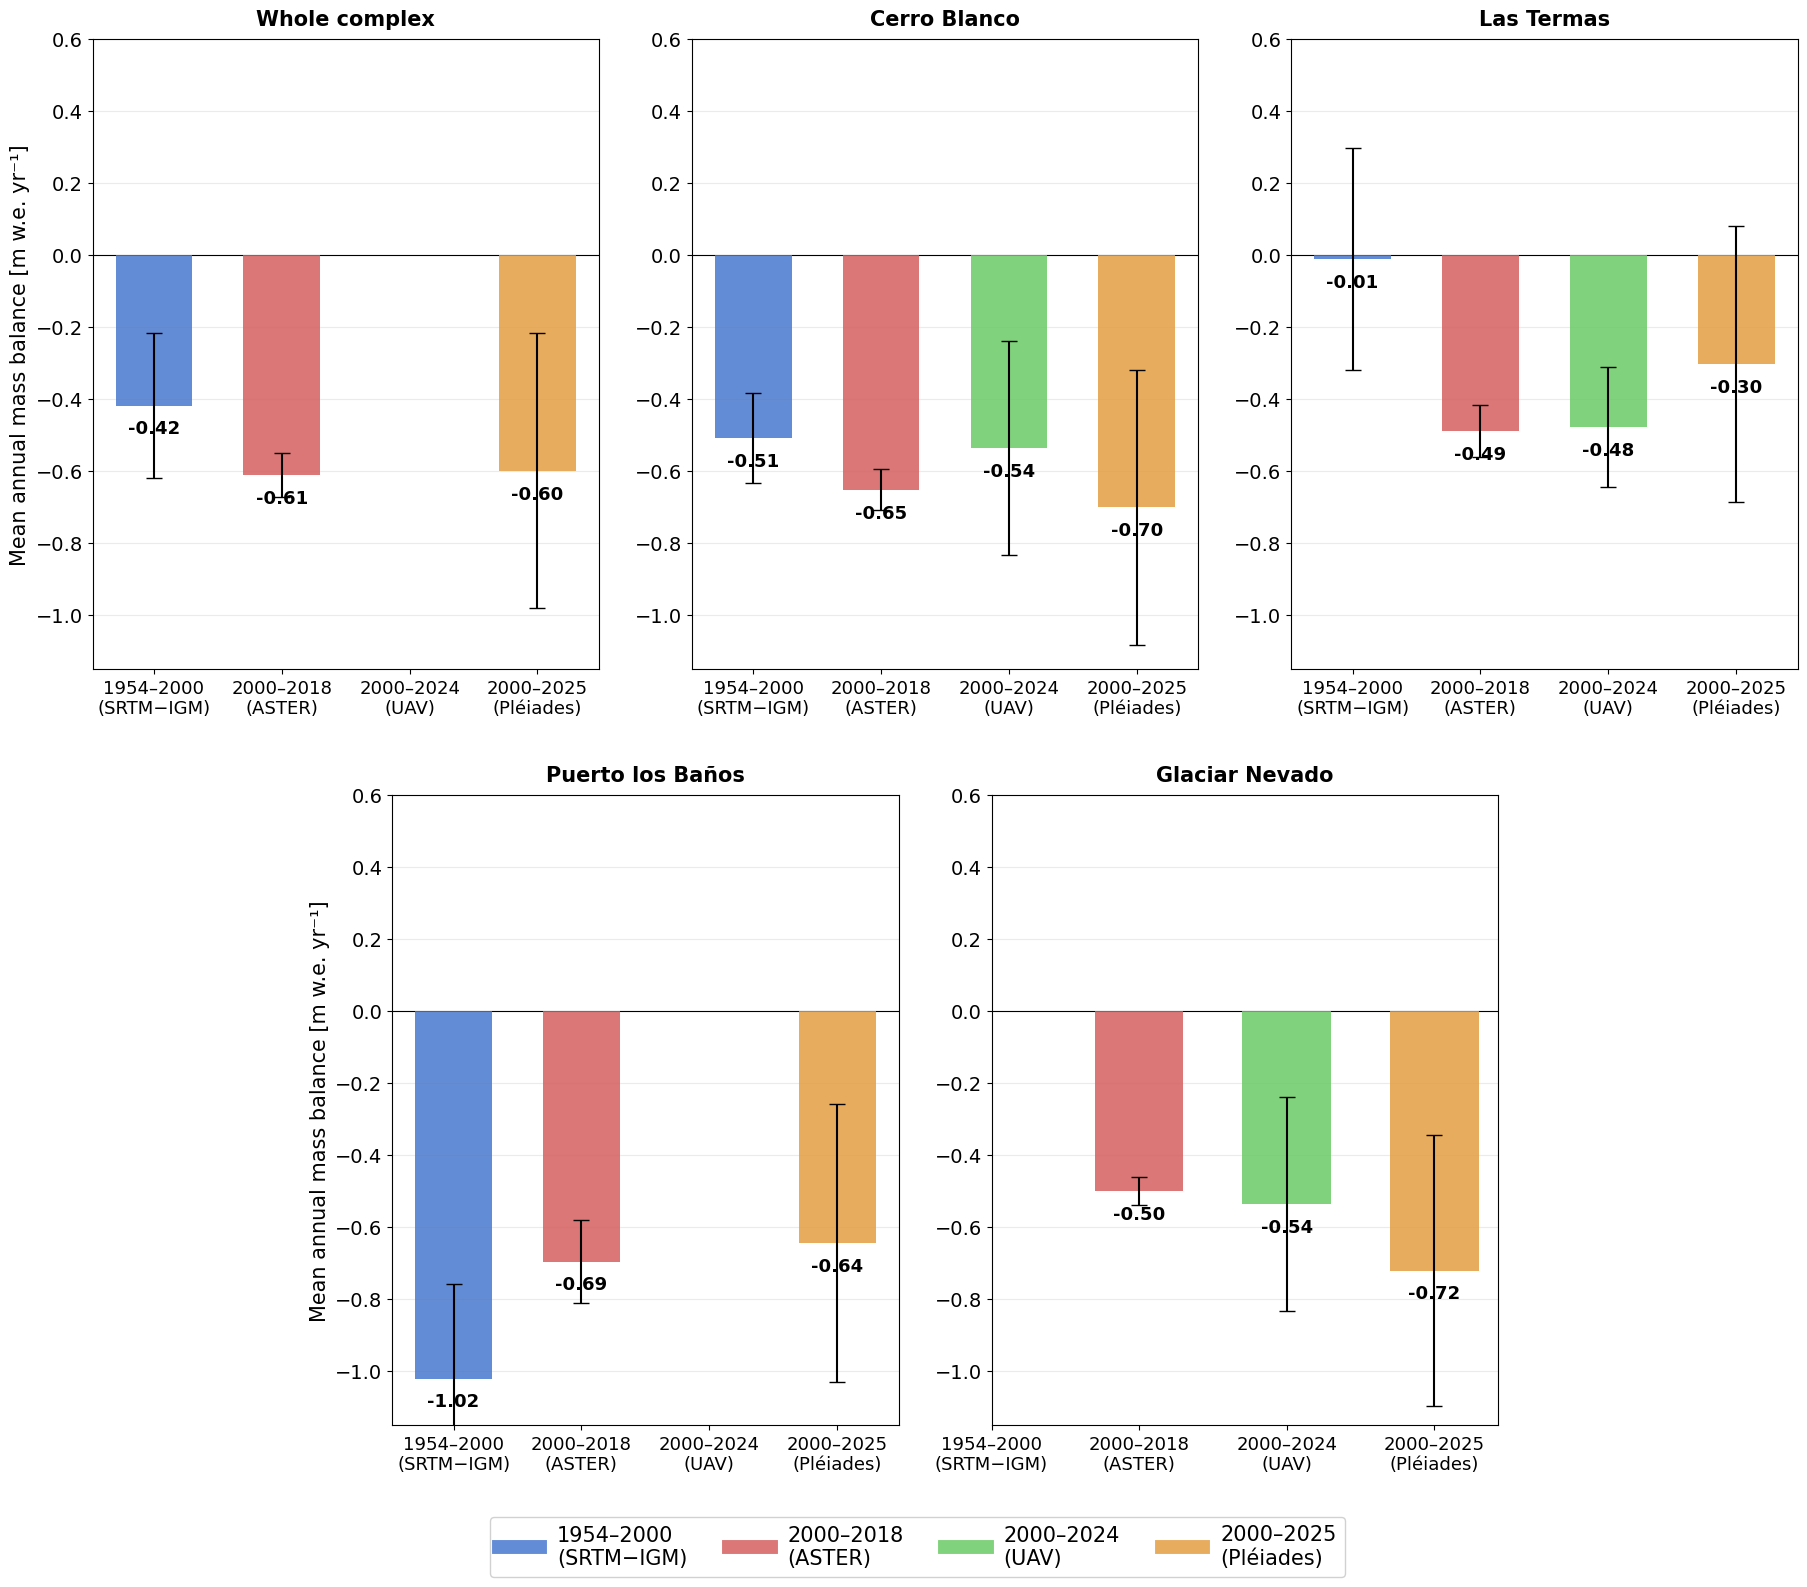

Saved: fig05_mass_balance_summary.png


In [46]:
#### FIGURE 5 ######
# ── Load MB results ────────────────────────────────────────────────────────
df_mb = pd.read_csv(os.path.join(results_folder, 'mass_balance_summary.csv'))

def get_mb(epoch, subcomplex):
    row = df_mb[(df_mb['epoch'] == epoch) & (df_mb['subcomplex'] == subcomplex)]
    if len(row) == 0:
        return np.nan, np.nan
    return float(row['mb_mwe_yr'].values[0]), float(row['sigma_mb_mwe_yr'].values[0])

# ── Epoch definitions ──────────────────────────────────────────────────────
EPOCHS = [
    ('1954–2000\n(SRTM−IGM)',  'SRTM_2000_minus_IGM_1954'),
    ('2000–2018\n(ASTER)',      'ASTER_20180301_minus_SRTM_2000'),
    ('2000–2024\n(UAV)',        None),
    ('2000–2025\n(Pléiades)',   'Pleiades_2025_minus_SRTM_2000'),
]

UAV_EPOCHS = {
    'Whole complex':    None,
    'Cerro Blanco':     'CerroBlanco_2024_minus_SRTM_2000',
    'Las Termas':       'LasTermas_2024_minus_SRTM_2000',
    'Puerto los Baños': None,
    'Glaciar Nevado':   'CerroBlanco_2024_minus_SRTM_2000',
}

SUBCOMPLEXES = ['Whole complex', 'Cerro Blanco', 'Las Termas',
                'Puerto los Baños', 'Glaciar Nevado']

# ── Build data arrays ──────────────────────────────────────────────────────
plot_data = {}
for sub in SUBCOMPLEXES:
    mb_list, sigma_list = [], []
    for label, epoch_key in EPOCHS:
        if epoch_key is None:
            uav_key = UAV_EPOCHS.get(sub)
            if uav_key:
                mb, sigma = get_mb(uav_key, sub)
            else:
                mb, sigma = np.nan, np.nan
        else:
            mb, sigma = get_mb(epoch_key, sub)
        mb_list.append(mb)
        sigma_list.append(sigma)
    plot_data[sub] = {'mb': mb_list, 'sigma': sigma_list}

# ── Plot ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        15,
    'axes.titlesize':   15,
    'axes.labelsize':   15,
    'xtick.labelsize':  14,
    'ytick.labelsize':  14,
    'legend.fontsize':  15,
})

n_epochs = len(EPOCHS)
x        = np.arange(n_epochs)
width    = 0.6
colors   = ['#4878CF', '#D65F5F', '#6ACC65', '#E59E42']

# Row 1: Whole complex, Cerro Blanco, Las Termas (3 panels)
# Row 2: Puerto los Baños, Glaciar Nevado (2 panels, centred)
fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(2, 6, figure=fig,
                         hspace=0.2, wspace=0.45)

# Row 1 — 3 equal panels spanning 2 columns each
ax_positions_r1 = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
]
# Row 2 — 2 panels centred (cols 1:3 and 3:5)
ax_positions_r2 = [
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]

all_axes = ax_positions_r1 + ax_positions_r2

# Share y axis across all panels
ylim = (-1.15, 0.6)

for ax, sub in zip(all_axes, SUBCOMPLEXES):
    mb    = plot_data[sub]['mb']
    sigma = plot_data[sub]['sigma']

    for i, (val, err, col) in enumerate(zip(mb, sigma, colors)):
        if not np.isnan(val):
            ax.bar(x[i], val, width,
                   yerr=err if not np.isnan(err) else 0,
                   capsize=6, color=col, alpha=0.85, zorder=3)
            offset = -0.04 if val < 0 else 0.04
            va     = 'top' if val < 0 else 'bottom'
            ax.text(x[i], val + offset, f'{val:.2f}',
                    ha='center', va=va, fontsize=13, fontweight='bold')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([e[0] for e in EPOCHS], fontsize=13)
    ax.set_title(sub, fontsize=15, fontweight='bold', pad=10)
    ax.grid(True, axis='y', alpha=0.25)
    ax.set_ylim(ylim)

# y-axis label on leftmost panel of each row
ax_positions_r1[0].set_ylabel('Mean annual mass balance [m w.e. yr⁻¹]', fontsize=15)
ax_positions_r2[0].set_ylabel('Mean annual mass balance [m w.e. yr⁻¹]', fontsize=15)

# Shared legend
legend_handles = [
    mlines.Line2D([], [], color=col, linewidth=10, alpha=0.85, label=label)
    for (label, _), col in zip(EPOCHS, colors)
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=4, fontsize=15, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.02))

fig.savefig(os.path.join(figures_folder, 'fig05_mass_balance_summary.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig05_mass_balance_summary.png')

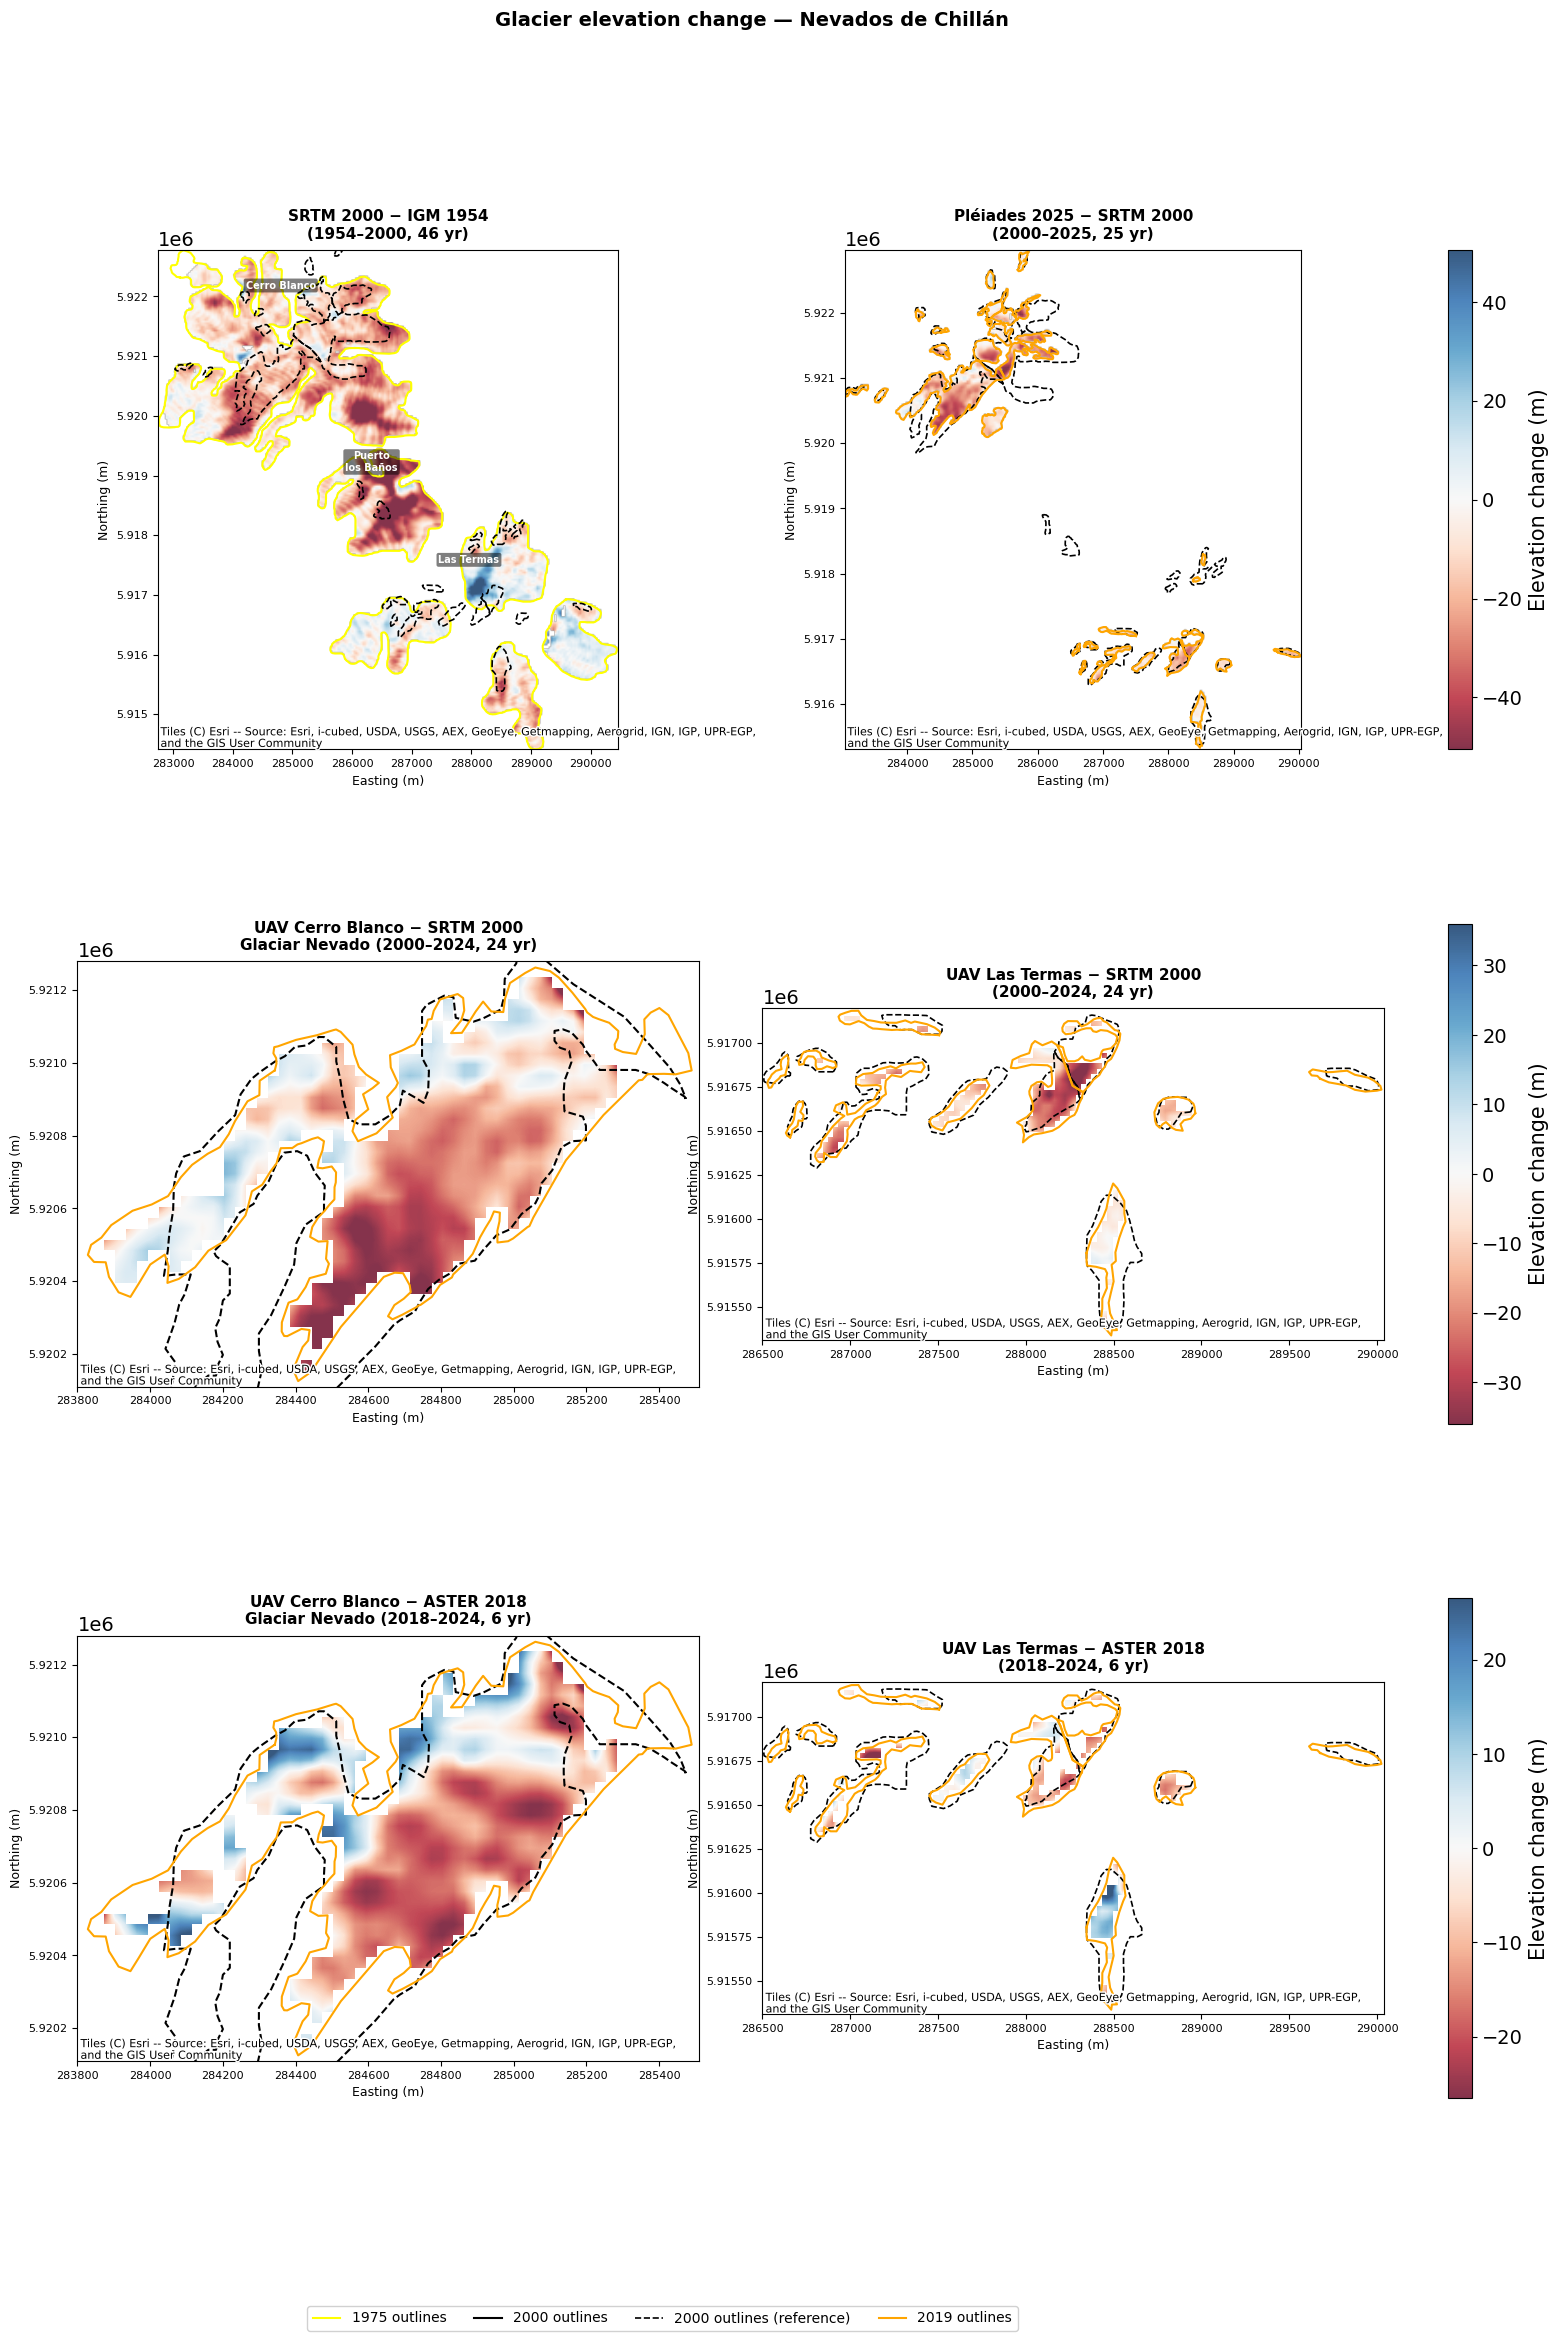

Saved: figures/fig_dh_maps.png


In [47]:
# ==============================================================================
# Multi-panel dh map — clipped to glacier polygons
# Row 1: SRTM-IGM (whole complex), Pleiades-SRTM (whole complex)
# Row 2: UAV CerroBlanco-SRTM, UAV LasTermas-SRTM
# Row 3: UAV CerroBlanco-ASTER 2018, UAV LasTermas-ASTER 2018
# ==============================================================================

gdf_2000 = gpd.read_file(glacier_2000_path).to_crs('EPSG:32719')
gdf_2019 = gpd.read_file(glacier_2019_path).to_crs('EPSG:32719')
gdf_2019['COD_GLA'] = gdf_2019['COD_GLA'].str.rstrip('@')
gdf_2019 = gdf_2019[gdf_2019['COD_GLA'].notna()]
gdf_1975 = gpd.read_file(glacier_1975_path).to_crs('EPSG:32719')

cb_2000     = gdf_2000[gdf_2000['COD_GLA'].isin(CERRO_BLANCO_GLACIERS)]
lt_2000     = gdf_2000[gdf_2000['COD_GLA'].isin(LASTERMAS_GLACIERS)]
sd_2000     = gdf_2000[gdf_2000['COD_GLA'].isin(SADDLE_GLACIERS)]
cb_2019     = gdf_2019[gdf_2019['COD_GLA'].isin(CERRO_BLANCO_GLACIERS)]
lt_2019     = gdf_2019[gdf_2019['COD_GLA'].isin(LASTERMAS_GLACIERS)]
nevado_2000 = gdf_2000[gdf_2000['COD_GLA'] == GLACIAR_NEVADO]
nevado_2019 = gdf_2019[gdf_2019['COD_GLA'] == GLACIAR_NEVADO]

def clip_dh_to_outlines(dh_path, outlines_gdf):
    outlines_gdf = outlines_gdf[outlines_gdf.geometry.notna()]
    outlines_gdf = outlines_gdf[~outlines_gdf.geometry.is_empty]
    with rasterio.open(dh_path) as src:
        outlines_proj = outlines_gdf.to_crs(src.crs)
        geoms = [g.__geo_interface__ for g in outlines_proj.geometry]
        try:
            clipped, transform = rio_mask(src, geoms, crop=True,
                                          nodata=np.nan, filled=True)
            arr = clipped[0].astype(float)
            arr[arr == src.nodata] = np.nan
        except Exception:
            arr = src.read(1).astype(float)
            arr[arr == src.nodata] = np.nan
            transform = src.transform
        bounds = rasterio.transform.array_bounds(
            arr.shape[0], arr.shape[1], transform)
        crs = src.crs
    extent = [bounds[0], bounds[2], bounds[1], bounds[3]]
    return arr, extent, crs, transform

def add_outlines(ax, outline_styles):
    for gdf, color, lw, ls in outline_styles:
        for geom in gdf.geometry:
            if geom is None or geom.is_empty:
                continue
            if geom.geom_type == 'Polygon':
                ax.plot(*geom.exterior.xy, color=color, linewidth=lw, linestyle=ls)
            elif geom.geom_type == 'MultiPolygon':
                for poly in geom.geoms:
                    ax.plot(*poly.exterior.xy, color=color, linewidth=lw, linestyle=ls)

# ── Load and clip all dh rasters ──────────────────────────────────────────────
dh1, ext1, crs, _ = clip_dh_to_outlines(
    'differenced_dems/SRTM_2000_minus_IGM_1954_dh.tif',           gdf_1975)
dh2, ext2, _,   _ = clip_dh_to_outlines(
    'differenced_dems/Pleiades_2025_minus_SRTM_2000_dh.tif',      gdf_2019)
dh3, ext3, _,   _ = clip_dh_to_outlines(
    'differenced_dems/CerroBlanco_2024_minus_SRTM_2000_dh.tif',   nevado_2019)
dh4, ext4, _,   _ = clip_dh_to_outlines(
    'differenced_dems/LasTermas_2024_minus_SRTM_2000_dh.tif',     lt_2019)
dh5, ext5, _,   _ = clip_dh_to_outlines(
    'differenced_dems/CerroBlanco_2024_minus_ASTER_20180301_dh.tif', nevado_2019)
dh6, ext6, _,   _ = clip_dh_to_outlines(
    'differenced_dems/LasTermas_2024_minus_ASTER_20180301_dh.tif',   lt_2019)

# ── Shared clim per row ───────────────────────────────────────────────────────
valid_top = np.concatenate([dh1[np.isfinite(dh1)], dh2[np.isfinite(dh2)]])
clim_top  = np.nanpercentile(np.abs(valid_top), 97)

valid_mid = np.concatenate([dh3[np.isfinite(dh3)], dh4[np.isfinite(dh4)]])
clim_mid  = np.nanpercentile(np.abs(valid_mid), 97)

valid_bot = np.concatenate([dh5[np.isfinite(dh5)], dh6[np.isfinite(dh6)]])
clim_bot  = np.nanpercentile(np.abs(valid_bot), 97)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 24))
gs  = GridSpec(3, 3, figure=fig,
               width_ratios=[1, 1, 0.04],
               hspace=0.35, wspace=0.15)

ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
ax20 = fig.add_subplot(gs[2, 0])
ax21 = fig.add_subplot(gs[2, 1])
cax_top = fig.add_subplot(gs[0, 2])
cax_mid = fig.add_subplot(gs[1, 2])
cax_bot = fig.add_subplot(gs[2, 2])

def plot_dh_panel(ax, dh, extent, outline_styles, title, clim, zoom=13):
    try:
        ctx.add_basemap(ax, crs=crs.to_string(),
                        source=ctx.providers.Esri.WorldImagery, zoom=zoom)
    except Exception as e:
        print(f'Basemap failed: {e}')
    im = ax.imshow(dh, extent=extent, origin='upper',
                   cmap='RdBu', vmin=-clim, vmax=clim,
                   alpha=0.8, interpolation='bilinear')
    add_outlines(ax, outline_styles)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_ylabel('Northing (m)', fontsize=9)
    ax.tick_params(labelsize=8)
    return im

# ── Row 1: whole complex ──────────────────────────────────────────────────────
im1 = plot_dh_panel(ax00, dh1, ext1,
    [(gdf_1975, 'yellow', 1.5, '-'), (gdf_2000, 'black', 1.2, '--')],
    'SRTM 2000 − IGM 1954\n(1954–2000, 46 yr)', clim_top)

label_offset = (ext1[3] - ext1[2]) * 0.06
for name, gdf in [('Cerro Blanco', cb_2000),
                  ('Las Termas',   lt_2000),
                  ('Puerto\nlos Baños', sd_2000)]:
    if len(gdf) > 0:
        cx = gdf.geometry.centroid.x.mean()
        cy = gdf.geometry.centroid.y.mean() + label_offset
        ax00.text(cx, cy, name, fontsize=7, color='white', ha='center',
                  fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='black',
                            alpha=0.5, edgecolor='none'))

im2 = plot_dh_panel(ax01, dh2, ext2,
    [(gdf_2000, 'black', 1.2, '--'), (gdf_2019, 'orange', 1.5, '-')],
    'Pléiades 2025 − SRTM 2000\n(2000–2025, 25 yr)', clim_top)

# ── Row 2: UAV vs SRTM ───────────────────────────────────────────────────────
im3 = plot_dh_panel(ax10, dh3, ext3,
    [(nevado_2000, 'black', 1.5, '--'), (nevado_2019, 'orange', 1.5, '-')],
    'UAV Cerro Blanco − SRTM 2000\nGlaciar Nevado (2000–2024, 24 yr)',
    clim_mid, zoom=14)

im4 = plot_dh_panel(ax11, dh4, ext4,
    [(lt_2000, 'black', 1.2, '--'), (lt_2019, 'orange', 1.5, '-')],
    'UAV Las Termas − SRTM 2000\n(2000–2024, 24 yr)',
    clim_mid, zoom=14)

# ── Row 3: UAV vs ASTER 2018 ──────────────────────────────────────────────────
im5 = plot_dh_panel(ax20, dh5, ext5,
    [(nevado_2000, 'black', 1.5, '--'), (nevado_2019, 'orange', 1.5, '-')],
    'UAV Cerro Blanco − ASTER 2018\nGlaciar Nevado (2018–2024, 6 yr)',
    clim_bot, zoom=14)

im6 = plot_dh_panel(ax21, dh6, ext6,
    [(lt_2000, 'black', 1.2, '--'), (lt_2019, 'orange', 1.5, '-')],
    'UAV Las Termas − ASTER 2018\n(2018–2024, 6 yr)',
    clim_bot, zoom=14)

# ── Colorbars ─────────────────────────────────────────────────────────────────
fig.colorbar(im1, cax=cax_top, label='Elevation change (m)')
fig.colorbar(im3, cax=cax_mid, label='Elevation change (m)')
fig.colorbar(im5, cax=cax_bot, label='Elevation change (m)')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], color='yellow', linewidth=1.5, linestyle='-',  label='1975 outlines'),
    Line2D([0],[0], color='black',  linewidth=1.5, linestyle='-',  label='2000 outlines'),
    Line2D([0],[0], color='black',  linewidth=1.2, linestyle='--', label='2000 outlines (reference)'),
    Line2D([0],[0], color='orange', linewidth=1.5, linestyle='-',  label='2019 outlines'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.45, 0.01), framealpha=0.9)

fig.suptitle('Glacier elevation change — Nevados de Chillán',
             fontsize=14, fontweight='bold')
fig.savefig(os.path.join(figures_folder, 'fig_dh_maps.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', os.path.join(figures_folder, 'fig_dh_maps.png'))

Total glacier area:
  1975: 16.02 km²
  2000: 2.91 km²
  2019: 1.90 km²
  1975→2000: -13.11 km² (-81.8%)
  2000→2019: -1.01 km² (-34.7%)
  1975→2019: -14.12 km² (-88.1%)

Per-subcomplex area change (km²):
Subcomplex               1975     2000     2019   Δ75-00   Δ00-19    Δ%75-19
---------------------------------------------------------------------------
Cerro Blanco              N/A     2.10     0.87      N/A    -1.23     -58.4%
Las Termas                N/A     0.74     0.45      N/A    -0.29     -39.5%
Puerto los Baños          N/A     0.07     0.00      N/A    -0.07    -100.0%

Area change vs elevation change by glacier (2000→2019, Pléiades):
COD_GLA          Area_2000  Area_2019   Δarea%    dh_yr    mb_yr
-----------------------------------------------------------------
CL108101046           1.23       0.00   -100.0    1.665    1.416
CL108130001           1.93       0.00   -100.0   -0.082   -0.070
CL108130002           4.90       0.00   -100.0   -1.022   -0.869
CL108101047       

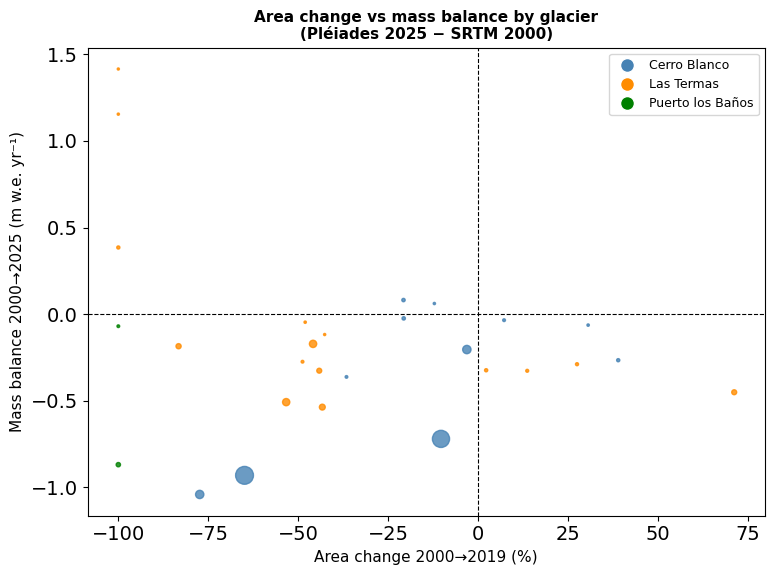

Saved: figures/area_change_vs_mb.png


In [48]:
# ==============================================================================
# Reviewer response: area change vs elevation change by subcomplex
# ==============================================================================

# Load all three outlines
gdf_1975 = gpd.read_file(glacier_1975_path).to_crs('EPSG:32719')
gdf_1975['COD_GLA'] = gdf_1975['Id'].astype(str) + '_1975'
gdf_2000 = gpd.read_file(glacier_2000_path).to_crs('EPSG:32719')
gdf_2019 = gpd.read_file(glacier_2019_path).to_crs('EPSG:32719')
gdf_2019['COD_GLA'] = gdf_2019['COD_GLA'].str.rstrip('@')
gdf_2019 = gdf_2019[gdf_2019['COD_GLA'].notna()]

# Compute areas
area_1975 = gdf_1975.geometry.area.sum() / 1e6
area_2000 = gdf_2000.geometry.area.sum() / 1e6
area_2019 = gdf_2019.geometry.area.sum() / 1e6

print(f'Total glacier area:')
print(f'  1975: {area_1975:.2f} km²')
print(f'  2000: {area_2000:.2f} km²')
print(f'  2019: {area_2019:.2f} km²')
print(f'  1975→2000: {area_2000 - area_1975:.2f} km² ({(area_2000/area_1975 - 1)*100:.1f}%)')
print(f'  2000→2019: {area_2019 - area_2000:.2f} km² ({(area_2019/area_2000 - 1)*100:.1f}%)')
print(f'  1975→2019: {area_2019 - area_1975:.2f} km² ({(area_2019/area_1975 - 1)*100:.1f}%)')

# Per-subcomplex area change
subcomplex_map = {
    'Cerro Blanco':     CERRO_BLANCO_GLACIERS,
    'Las Termas':       LASTERMAS_GLACIERS,
    'Puerto los Baños': SADDLE_GLACIERS,
}

print(f'\nPer-subcomplex area change (km²):')
print(f'{"Subcomplex":<20} {"1975":>8} {"2000":>8} {"2019":>8} {"Δ75-00":>8} {"Δ00-19":>8} {"Δ%75-19":>10}')
print('-' * 75)

for name, ids in subcomplex_map.items():
    a00 = gdf_2000[gdf_2000['COD_GLA'].isin(ids)].geometry.area.sum() / 1e6
    a19 = gdf_2019[gdf_2019['COD_GLA'].isin(ids)].geometry.area.sum() / 1e6
    pct = (a19/a00 - 1)*100 if a00 > 0 else np.nan
    print(f'{name:<20} {"N/A":>8} {a00:>8.2f} {a19:>8.2f} {"N/A":>8} {a19-a00:>8.2f} {pct:>9.1f}%')

# Load results
df = pd.read_csv('results/glacier_elevation_change_results.csv')

print(f'\nArea change vs elevation change by glacier (2000→2019, Pléiades):')
print(f'{"COD_GLA":<15} {"Area_2000":>10} {"Area_2019":>10} {"Δarea%":>8} {"dh_yr":>8} {"mb_yr":>8}')
print('-' * 65)

pleiades = df[
    (df['epoch'] == 'Pleiades_2025_minus_SRTM_2000') &
    (df['clip_outline'] == 2000) &
    (df['mb_mwe_yr'].notna())
][['COD_GLA', 'area_start_m2', 'area_end_m2', 'dh_yr_m', 'mb_mwe_yr']].copy()

pleiades['area_change_pct'] = (pleiades['area_end_m2'] / pleiades['area_start_m2'] - 1) * 100

for _, row in pleiades.sort_values('area_change_pct').iterrows():
    print(f'{row.COD_GLA:<15} {row.area_start_m2/1e4:>10.2f} {row.area_end_m2/1e4:>10.2f} '
          f'{row.area_change_pct:>8.1f} {row.dh_yr_m:>8.3f} {row.mb_mwe_yr:>8.3f}')

# Scatter: area change vs mb
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if c in CERRO_BLANCO_GLACIERS
          else 'darkorange' if c in LASTERMAS_GLACIERS
          else 'green' for c in pleiades['COD_GLA']]

ax.scatter(pleiades['area_change_pct'], pleiades['mb_mwe_yr'],
           c=colors, alpha=0.8, s=pleiades['area_start_m2']/5000)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Area change 2000→2019 (%)', fontsize=11)
ax.set_ylabel('Mass balance 2000→2025 (m w.e. yr⁻¹)', fontsize=11)
ax.set_title('Area change vs mass balance by glacier\n(Pléiades 2025 − SRTM 2000)',
             fontsize=11, fontweight='bold')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=10, label='Cerro Blanco'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange',
           markersize=10, label='Las Termas'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
           markersize=10, label='Puerto los Baños'),
]
ax.legend(handles=legend_elements, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(figures_folder, 'area_change_vs_mb.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', os.path.join(figures_folder, 'area_change_vs_mb.png'))

In [49]:
print("\nNotebook 3 complete.")
print(f"  Results:  {results_folder}/")
print(f"  Figures:  {figures_folder}/")
print(f"  dh maps:  {output_folder}/")


Notebook 3 complete.
  Results:  results/
  Figures:  figures/
  dh maps:  differenced_dems/


In [50]:
## check results 

df = pd.read_csv('results/glacier_elevation_change_results.csv')
mb  = pd.read_csv('results/mass_balance_summary.csv')

# 1. Check all expected columns are present
expected_cols = ['sigma_mb_mwe_yr', 'sigma_mb_elev_mwe_yr', 
                 'sigma_mb_density_mwe_yr', 'area_end_m2', 'area_mean_m2']
print('=== Column check ===')
for col in expected_cols:
    print(f'  {col}: {"✓" if col in df.columns else "MISSING"}')

# 2. Check Pléiades uncertainty is now reasonable
pleiades = df[df['epoch'] == 'Pleiades_2025_minus_SRTM_2000']
print(f'\n=== Pléiades-SRTM uncertainty ===')
print(f'  sigma_mb_mwe_yr range: '
      f'{pleiades["sigma_mb_mwe_yr"].min():.3f} to '
      f'{pleiades["sigma_mb_mwe_yr"].max():.3f}')
print(f'  sigma_mb_elev range:   '
      f'{pleiades["sigma_mb_elev_mwe_yr"].min():.3f} to '
      f'{pleiades["sigma_mb_elev_mwe_yr"].max():.3f}')

# 3. Check fragmentation fix — CL108101048 should have area_end > 0
frag = df[(df['COD_GLA'] == 'CL108101048') & 
          (df['epoch'] == 'Pleiades_2025_minus_SRTM_2000')]
print(f'\n=== Fragmentation check (CL108101048) ===')
if len(frag) > 0:
    print(f'  area_start: {frag["area_start_m2"].values[0]/1e4:.2f} ha')
    print(f'  area_end:   {frag["area_end_m2"].values[0]/1e4:.2f} ha')
    print(f'  area_mean:  {frag["area_mean_m2"].values[0]/1e4:.2f} ha')
else:
    print('  NOT FOUND')

# 4. Check disappeared glaciers have area_end = 0
print(f'\n=== Disappeared glaciers (should have area_end = 0) ===')
for gid in ['CL108130001', 'CL108130002', 'CL108101046']:
    row = df[(df['COD_GLA'] == gid) & 
             (df['epoch'] == 'Pleiades_2025_minus_SRTM_2000')]
    if len(row) > 0:
        print(f'  {gid}: area_end = {row["area_end_m2"].values[0]:.1f} m²')

# 5. Key MB summary
print(f'\n=== Key whole-complex MB values ===')
key_epochs = [
    ('SRTM_2000_minus_IGM_1954',      'Whole complex', '1954-2000'),
    ('ASTER_20180301_minus_SRTM_2000', 'Whole complex', '2000-2018'),
    ('Pleiades_2025_minus_SRTM_2000',  'Whole complex', '2000-2025'),
]
for epoch, sub, label in key_epochs:
    row = mb[(mb['epoch'] == epoch) & (mb['subcomplex'] == sub)]
    if len(row) > 0:
        print(f'  {label}: {row["mb_mwe_yr"].values[0]:.3f} '
              f'± {row["sigma_mb_mwe_yr"].values[0]:.3f} m w.e. yr⁻¹')

=== Column check ===
  sigma_mb_mwe_yr: ✓
  sigma_mb_elev_mwe_yr: ✓
  sigma_mb_density_mwe_yr: ✓
  area_end_m2: ✓
  area_mean_m2: ✓

=== Pléiades-SRTM uncertainty ===
  sigma_mb_mwe_yr range: 0.376 to 0.395
  sigma_mb_elev range:   0.372 to 0.383

=== Fragmentation check (CL108101048) ===
  area_start: 82.77 ha
  area_end:   29.03 ha
  area_mean:  55.90 ha

=== Disappeared glaciers (should have area_end = 0) ===
  CL108130001: area_end = 0.0 m²
  CL108130002: area_end = 0.0 m²
  CL108101046: area_end = 0.0 m²

=== Key whole-complex MB values ===
  1954-2000: -0.417 ± 0.201 m w.e. yr⁻¹
  2000-2018: -0.610 ± 0.062 m w.e. yr⁻¹
  2000-2025: -0.598 ± 0.382 m w.e. yr⁻¹


In [51]:
# Visualize MB summary 
mb = pd.read_csv('results/mass_balance_summary.csv')
print(mb.to_string())

                                    epoch  t_start  t_end  dt_yr        subcomplex  n_glaciers  total_area_km2  mb_mwe_yr  sigma_mb_mwe_yr  dV_we_km3  dV_we_km3_yr
0          ASTER_20180301_minus_SRTM_2000     2000   2018     18      Cerro Blanco          11           1.723     -0.651            0.057    -0.0202      -0.00112
1          ASTER_20180301_minus_SRTM_2000     2000   2018     18        Las Termas          15           0.597     -0.488            0.073    -0.0052      -0.00029
2          ASTER_20180301_minus_SRTM_2000     2000   2018     18  Puerto los Baños           2           0.034     -0.695            0.115    -0.0004      -0.00002
3          ASTER_20180301_minus_SRTM_2000     2000   2018     18     Whole complex          28           2.354     -0.610            0.062    -0.0259      -0.00144
4          ASTER_20180301_minus_SRTM_2000     2000   2018     18    Glaciar Nevado           1           0.724     -0.500            0.039    -0.0065      -0.00036
5   CerroBlanco_

## quick manuscript checks

In [53]:
import pandas as pd
import geopandas as gpd
import numpy as np

# Load results
df_px = pd.read_csv('results/pixel_dh_summary.csv')
df_mb = pd.read_csv('results/mass_balance_summary.csv')

# Q1: CB 1954-2024 cumulative thinning (mean dh × dt)
cb_igm = df_px[(df_px['epoch'] == 'CB UAV−IGM 1954–2024') & 
               (df_px['subcomplex'] == 'cerro_blanco')]
print('=== Q1: CB 1954-2024 cumulative thinning ===')
if len(cb_igm) > 0:
    mean_dh = cb_igm['mean_dh_m'].values[0]
    std_dh  = cb_igm['std_dh_m'].values[0]
    print(f'  Mean dh: {mean_dh:.1f} m')
    print(f'  Std dh:  {std_dh:.1f} m')
else:
    print('  Not found — check epoch label')

# Q2: LT 2000-2024 cumulative thinning
lt_srtm = df_px[(df_px['epoch'] == 'LT UAV−SRTM 2000–2024') & 
                (df_px['subcomplex'] == 'las_termas')]
print('\n=== Q2: LT 2000-2024 cumulative thinning ===')
if len(lt_srtm) > 0:
    mean_dh = lt_srtm['mean_dh_m'].values[0]
    std_dh  = lt_srtm['std_dh_m'].values[0]
    print(f'  Mean dh: {mean_dh:.1f} m')
    print(f'  Std dh:  {std_dh:.1f} m')
else:
    print('  Not found — check epoch label')

# Q3 and Q4: 1975 LT polygon area and current (2019) LT footprint
gdf_1975 = gpd.read_file('/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp').to_crs('EPSG:32719')
gdf_2019 = gpd.read_file('example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp').to_crs('EPSG:32719')
gdf_2019['COD_GLA'] = gdf_2019['COD_GLA'].str.rstrip('@')

# LT glaciers in 2019
LT_IDS = [
    'CL108130010','CL108100003','CL108100002','CL108100004','CL108130008',
    'CL108130003','CL108130007','CL108130006','CL108130005','CL108130004',
    'CL108100005','CL108100006','CL108101047','CL108101046','CL108130009',
    'CL108100006A','CL108100006B'
]
lt_2019 = gdf_2019[gdf_2019['COD_GLA'].isin(LT_IDS)]
lt_2019_area = lt_2019.geometry.area.sum() / 1e6

print('\n=== Q3: 1975 LT polygon total area ===')
print(f'  Total 1975 area (all polygons): {gdf_1975.geometry.area.sum()/1e6:.3f} km²')
print('  (Note: 1975 inventory has no subcomplex IDs — full complex area shown)')

print('\n=== Q4: LT current glacier footprint (2019) ===')
print(f'  LT 2019 area: {lt_2019_area:.3f} km²')

# Q5: LT IGM-based MB (positive value check)
lt_igm_mb = df_mb[(df_mb['epoch'] == 'LasTermas_2024_minus_IGM_1954') & 
                   (df_mb['subcomplex'] == 'Las Termas')]
print('\n=== Q5: LT 1954-based MB ===')
if len(lt_igm_mb) > 0:
    mb  = lt_igm_mb['mb_mwe_yr'].values[0]
    sig = lt_igm_mb['sigma_mb_mwe_yr'].values[0]
    print(f'  MB: {mb:.3f} ± {sig:.3f} m w.e. yr⁻¹')
else:
    print('  Not found — check epoch/subcomplex label')
    print('  Available epochs:', df_mb['epoch'].unique())
    print('  Available subcomplexes:', df_mb['subcomplex'].unique())

=== Q1: CB 1954-2024 cumulative thinning ===
  Mean dh: -28.0 m
  Std dh:  22.1 m

=== Q2: LT 2000-2024 cumulative thinning ===
  Mean dh: -11.6 m
  Std dh:  9.9 m

=== Q3: 1975 LT polygon total area ===
  Total 1975 area (all polygons): 16.021 km²
  (Note: 1975 inventory has no subcomplex IDs — full complex area shown)

=== Q4: LT current glacier footprint (2019) ===
  LT 2019 area: 0.458 km²

=== Q5: LT 1954-based MB ===
  MB: 0.063 ± 0.203 m w.e. yr⁻¹


In [54]:
cb_mb = df_mb[(df_mb['epoch'] == 'CerroBlanco_2024_minus_IGM_1954') & 
              (df_mb['subcomplex'] == 'Cerro Blanco')]
print(f"CB sigma: {cb_mb['sigma_mb_mwe_yr'].values[0]:.3f}")
print(f"CB uncertainty in m: {cb_mb['sigma_mb_mwe_yr'].values[0] * 70 / 0.85:.1f} m")

CB sigma: 0.054
CB uncertainty in m: 4.4 m


In [55]:
lt_mb = df_mb[(df_mb['epoch'] == 'LasTermas_2024_minus_SRTM_2000') & 
              (df_mb['subcomplex'] == 'Las Termas')]
print(f"LT sigma: {lt_mb['sigma_mb_mwe_yr'].values[0]:.3f}")
print(f"LT uncertainty in m: {lt_mb['sigma_mb_mwe_yr'].values[0] * 24 / 0.85:.1f} m")

LT sigma: 0.166
LT uncertainty in m: 4.7 m
